# Import Library: 분석에 사용할 모듈 설치
**1. Import Library**

In [1]:
!python -m pip install --user --upgrade pip

In [2]:
# Ignore the warnings
import warnings
# warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

# System related and data input controls
import os

# Python path
import sys
module_location = [os.path.join(os.getcwd().split('DataScience')[0],'DataScience','Module')] 
for each in module_location:
    if each not in sys.path:
        sys.path.append(each)

# Auto reload of library
%reload_ext autoreload
%autoreload 2

from install_import_KK import *
from preprocessing_KK import *
from algorithm_deeplearning_KK import *
from evaluation_KK import *

In [3]:
### Feature engineering of all
def feature_engineering(raw):
    if 'datetime' in raw.columns:
        raw['datetime'] = pd.to_datetime(raw['datetime'])
        raw['DateTime'] = pd.to_datetime(raw['datetime'])

    if raw.index.dtype == 'int64':
        raw.set_index('DateTime', inplace=True)

    raw = raw.asfreq('H', method='ffill')

    result = sm.tsa.seasonal_decompose(raw['count'], model='additive')
    Y_trend = pd.DataFrame(result.trend)
    Y_trend.fillna(method='ffill', inplace=True)
    Y_trend.fillna(method='bfill', inplace=True)
    Y_trend.columns = ['count_trend']
    Y_seasonal = pd.DataFrame(result.seasonal)
    Y_seasonal.fillna(method='ffill', inplace=True)
    Y_seasonal.fillna(method='bfill', inplace=True)
    Y_seasonal.columns = ['count_seasonal']
    pd.concat([raw, Y_trend, Y_seasonal], axis=1).isnull().sum()
    if 'count_trend' not in raw.columns:
        if 'count_seasonal' not in raw.columns:
            raw = pd.concat([raw, Y_trend, Y_seasonal], axis=1)

    Y_count_Day = raw[['count']].rolling(24).mean()
    Y_count_Day.fillna(method='ffill', inplace=True)
    Y_count_Day.fillna(method='bfill', inplace=True)
    Y_count_Day.columns = ['count_Day']
    Y_count_Week = raw[['count']].rolling(24*7).mean()
    Y_count_Week.fillna(method='ffill', inplace=True)
    Y_count_Week.fillna(method='bfill', inplace=True)
    Y_count_Week.columns = ['count_Week']
    if 'count_Day' not in raw.columns:
        raw = pd.concat([raw, Y_count_Day], axis=1)
    if 'count_Week' not in raw.columns:
        raw = pd.concat([raw, Y_count_Week], axis=1)

    Y_diff = raw[['count']].diff()
    Y_diff.fillna(method='ffill', inplace=True)
    Y_diff.fillna(method='bfill', inplace=True)
    Y_diff.columns = ['count_diff']
    if 'count_diff' not in raw.columns:
        raw = pd.concat([raw, Y_diff], axis=1)

    raw['temp_group'] = pd.cut(raw['temp'], 10)
    raw['Year'] = raw.datetime.dt.year
    raw['Quater'] = raw.datetime.dt.quarter
    raw['Quater_ver2'] = raw['Quater'] + (raw.Year - raw.Year.min()) * 4
    raw['Month'] = raw.datetime.dt.month
    raw['Day'] = raw.datetime.dt.day
    raw['Hour'] = raw.datetime.dt.hour
    raw['DayofWeek'] = raw.datetime.dt.dayofweek

    raw['count_lag1'] = raw['count'].shift(1)
    raw['count_lag2'] = raw['count'].shift(2)
    raw['count_lag1'].fillna(method='bfill', inplace=True)
    raw['count_lag2'].fillna(method='bfill', inplace=True)

    if 'Quater' in raw.columns:
        if 'Quater_Dummy' not in ['_'.join(col.split('_')[:2]) for col in raw.columns]:
            raw = pd.concat([raw, pd.get_dummies(raw['Quater'], 
                                                 prefix='Quater_Dummy', drop_first=True)], axis=1)
            del raw['Quater']
    raw_fe = raw.copy()
    return raw_fe


### duplicate previous year values to next one
def feature_engineering_year_duplicated(raw, target):
    raw_fe = raw.copy()
    for col in target:
        raw_fe.loc['2012-01-01':'2012-02-28', col] = raw.loc['2011-01-01':'2011-02-28', col].values
        raw_fe.loc['2012-03-01':'2012-12-31', col] = raw.loc['2011-03-01':'2011-12-31', col].values
        step = (raw.loc['2011-03-01 00:00:00', col] - raw.loc['2011-02-28 23:00:00', col])/25
        step_value = np.arange(raw.loc['2011-02-28 23:00:00', col]+step, raw.loc['2011-03-01 00:00:00', col], step)
        step_value = step_value[:24]
        raw_fe.loc['2012-02-29', col] = step_value
    return raw_fe


### modify lagged values of X_test
def feature_engineering_lag_modified(Y_test, X_test, target):
    X_test_lm = X_test.copy()
    for col in target:
        X_test_lm[col] = Y_test.shift(1).values
        X_test_lm[col].fillna(method='bfill', inplace=True)
        X_test_lm[col] = Y_test.shift(2).values
        X_test_lm[col].fillna(method='bfill', inplace=True)
    return X_test_lm


# Deep Learning: Bike Sharing Prediction

## Parameters Setting

In [4]:
tf.random.set_seed(123)
Y_colname = ['count']
X_remove = ['datetime', 'DateTime', 'temp_group', 'casual', 'registered']
SCALER = preprocessing.MinMaxScaler()
TEST_SIZE = 120
OUTPUT = 1
SEQUENCE = 20 # not MLP
DROPOUT_RATIO = 0.2
OPTIMIZER = 'adam'
BATCH_SIZE = 32
EPOCHS = 50 # 100
# Callback WalkForward
CALLBACK_TYPE = 'Optimal' # 'Process' or 'Optimal' or 'Dual'
EARLYSTOP_PATIENT = 10
#################
VERBOSE = 0
RESULT_LOCATION = os.path.join(os.getcwd(),'Result','Bike_Sharing_')
RESULT_DPI = 150
ALGO_NAMES = ['MLP', 'CNN', 'RNN', 'LSTM', 'GRU']

## MLP

Trasformed:
X_train: (260, 24) Y_train: (260, 1)
X_val: (120, 24) Y_val: (120, 1)
X_test: (120, 24) Y_test: (120, 1)
Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 24)]              0         
_________________________________________________________________
dense (Dense)                (None, 128)               3200      
_________________________________________________________________
dropout (Dropout)            (None, 128)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 64)                8256      
_________________________________________________________________
dropout_1 (Dropout)          (None, 64)                0         
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 65        
Total para

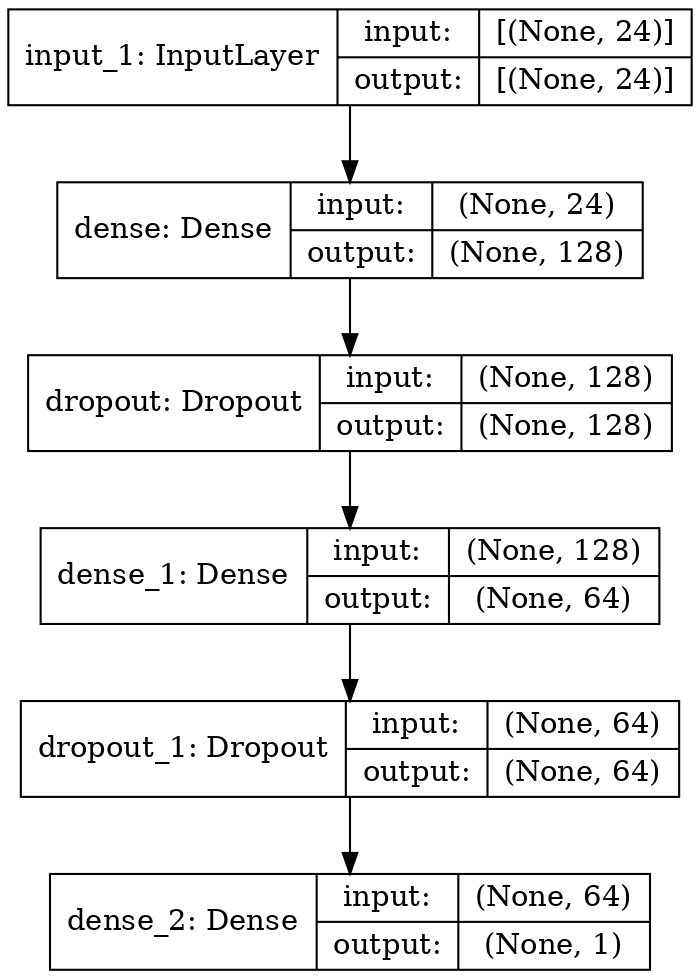

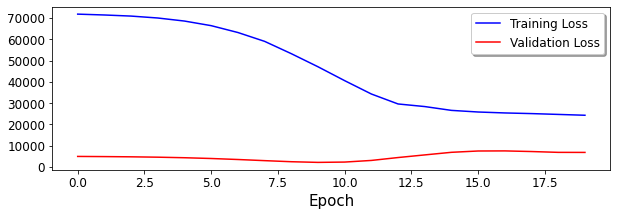

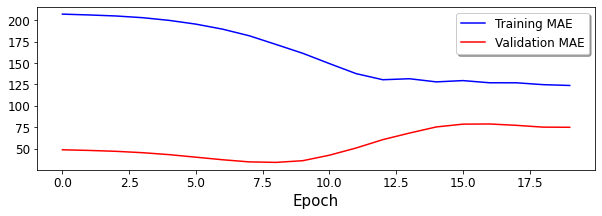

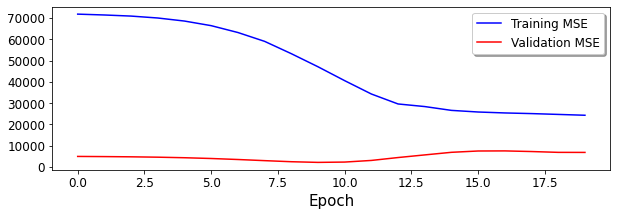

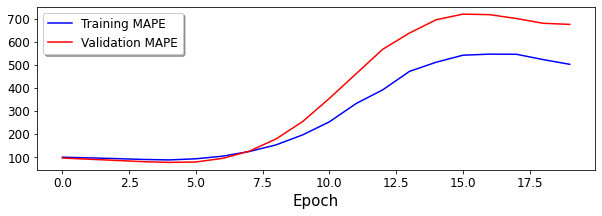

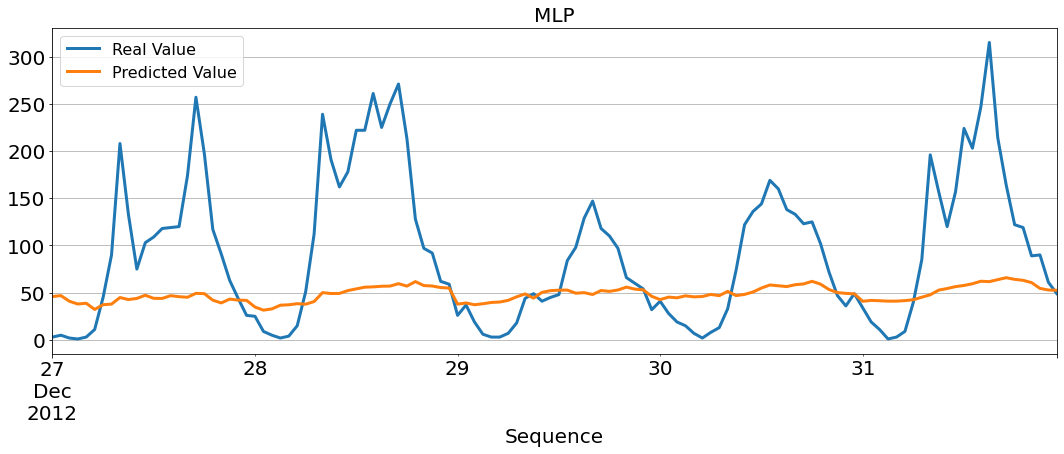

,MAE,MSE,MAPE
Score,61.53,"7,059.67",2.58


In [5]:
# Data Loading
location = os.path.join(os.getcwd(),'Data','BikeSharingDemand','Bike_Sharing_Demand_Full.csv')
df = pd.read_csv(location)

# Preprocessing
X_colname = [x for x in df.columns if x not in Y_colname+X_remove]
df = feature_engineering(df)
X_colname = [x for x in df.columns if x not in Y_colname+X_remove]
target = ['count_trend', 'count_seasonal', 'count_Day', 'count_Week', 'count_diff']
df = feature_engineering_year_duplicated(df, target)
df = df[Y_colname + X_colname].copy()
df = df[-500:].copy()

# Data Split and Scaling
X_train, Y_train, X_val, Y_val, X_test, Y_test = \
dl_preprocessing(df, Y_colname, TEST_SIZE=TEST_SIZE, SCALER=SCALER)

# MLP
algo_MLP = dl_MLP(X_train, OUTPUT, ACTIVATION='relu', DROPOUT_RATIO=DROPOUT_RATIO)
dl_show_structure(algo_MLP, RESULT_LOCATION=RESULT_LOCATION, 
                  RESULT_NAME='MLP.png', RESULT_DPI=150)

# Learning
algo_MLP, algo_MLPfit = dl_learning_reg(algo_MLP, X_train, Y_train, X_val, Y_val,
                                        OPTIMIZER=OPTIMIZER, 
                                        BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS,
                                        CALLBACK_TYPE=CALLBACK_TYPE, EARLYSTOP_PATIENT=EARLYSTOP_PATIENT,
                                        VERBOSE=VERBOSE, 
                                        RESULT_LOCATION=RESULT_LOCATION, RESULT_NAME='MLP.h5')
evaluation_reg_LearningPlot(algo_MLPfit)

# Prediction
Y_pred = algo_MLP.predict(X_test)
Y_pred = pd.DataFrame(Y_pred, index=Y_test.index, columns=Y_colname)

# Evaluation
evaluation_reg_PredPlot(Y_test, Y_pred, title='MLP', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_test, Y_pred)
display(Score)

# Summary
Score_MLP = Score.copy()
Y_pred_MLP = Y_pred.copy()

### Walk Forward

 99%|█████████▉| 119/120 [03:05<00:01,  1.68s/it]

Model: "model_120"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_121 (InputLayer)       [(None, 24)]              0         
_________________________________________________________________
dense_360 (Dense)            (None, 128)               3200      
_________________________________________________________________
dropout_240 (Dropout)        (None, 128)               0         
_________________________________________________________________
dense_361 (Dense)            (None, 64)                8256      
_________________________________________________________________
dropout_241 (Dropout)        (None, 64)                0         
_________________________________________________________________
dense_362 (Dense)            (None, 1)                 65        
Total params: 11,521
Trainable params: 11,521
Non-trainable params: 0
_____________________________________________________

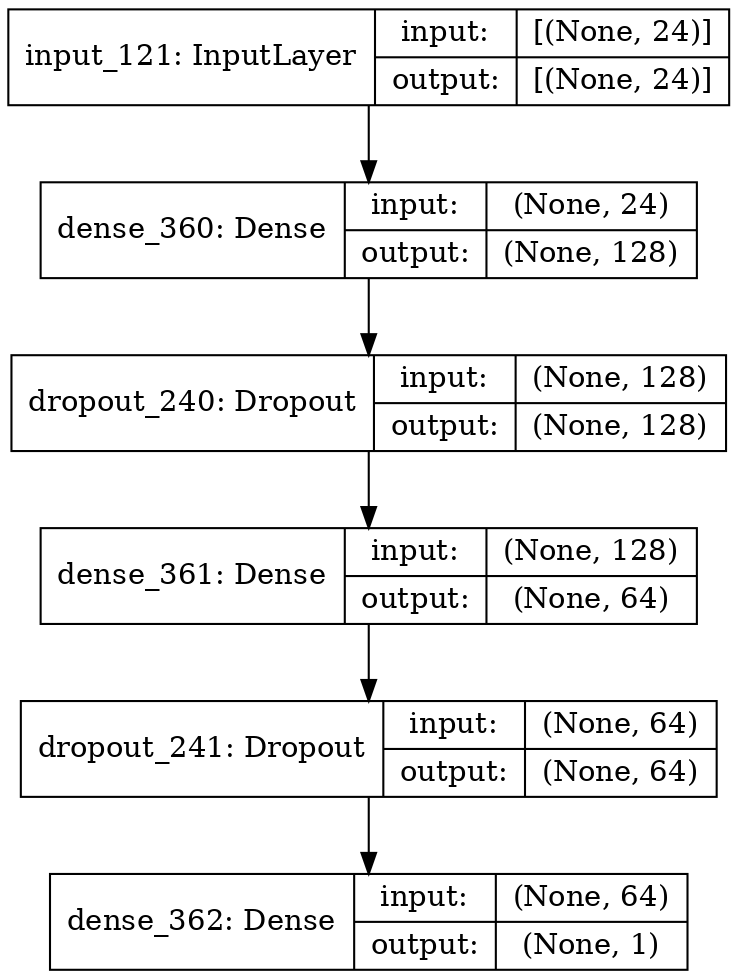

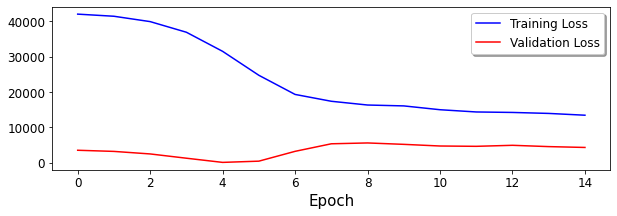

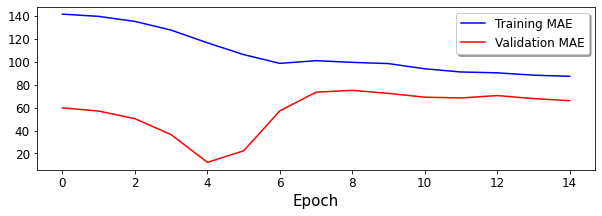

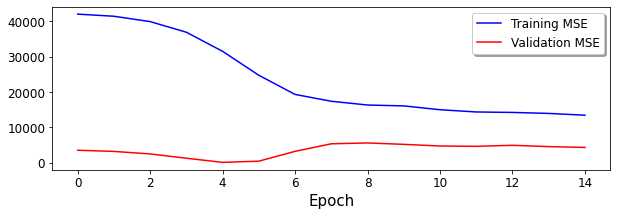

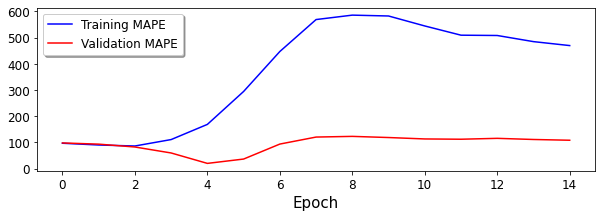

100%|██████████| 120/120 [03:07<00:00,  1.56s/it]


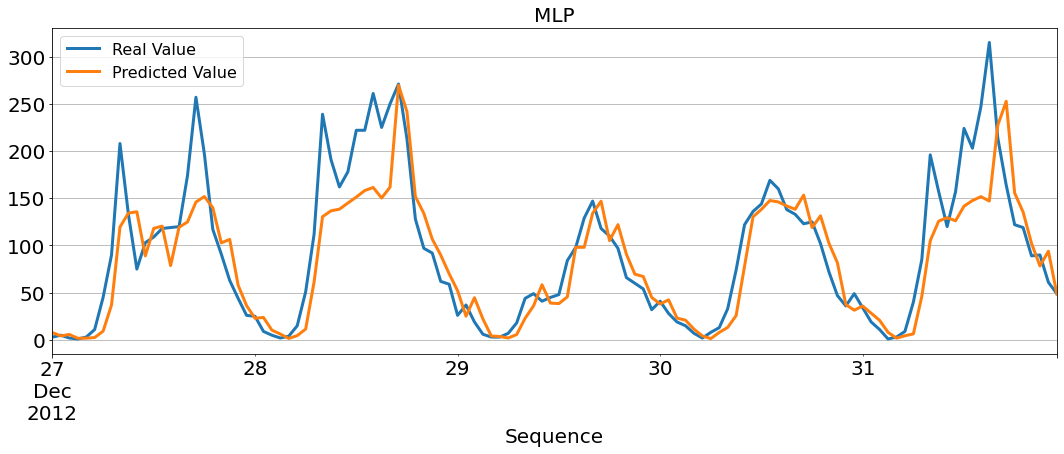

,MAE,MSE,MAPE
Score,26.12,"1,530.15",0.48


In [6]:
# Data Loading
location = os.path.join(os.getcwd(),'Data','BikeSharingDemand','Bike_Sharing_Demand_Full.csv')
df = pd.read_csv(location)

# Preprocessing
X_colname = [x for x in df.columns if x not in Y_colname+X_remove]
df = feature_engineering(df)
X_colname = [x for x in df.columns if x not in Y_colname+X_remove]
target = ['count_trend', 'count_seasonal', 'count_Day', 'count_Week', 'count_diff']
df = feature_engineering_year_duplicated(df, target)
df = df[Y_colname + X_colname].copy()
df = df[-500:].copy()

# Modeling
Y_real, Y_pred = pd.DataFrame(), pd.DataFrame()
spliter = TimeSeriesSplit(gap=0, n_splits=TEST_SIZE, test_size=OUTPUT)
for idx, (train_index, test_index) in tqdm(enumerate(spliter.split(df)), total=TEST_SIZE):
    # Data Split and Scaling
    X_train, Y_train, X_val, Y_val, X_test, Y_test = \
    dl_preprocessing_walkforward(df, Y_colname, train_index, test_index, 
                                 VAL_SIZE=OUTPUT, SCALER=SCALER)
    
    # MLP
    algo_MLP = dl_MLP(X_train, 1, ACTIVATION='relu', DROPOUT_RATIO=DROPOUT_RATIO)
    if (idx+1) == TEST_SIZE:
        dl_show_structure(algo_MLP, RESULT_LOCATION=RESULT_LOCATION, 
                          RESULT_NAME='MLP_Forward.png', RESULT_DPI=150)
    
    # Learning
    algo_MLP, algo_MLPfit = dl_learning_reg(algo_MLP, X_train, Y_train, X_val, Y_val,
                                            OPTIMIZER=OPTIMIZER, 
                                            BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS,
                                            CALLBACK_TYPE=CALLBACK_TYPE, EARLYSTOP_PATIENT=EARLYSTOP_PATIENT,
                                            VERBOSE=VERBOSE, 
                                            RESULT_LOCATION=RESULT_LOCATION, RESULT_NAME='MLP_Forward.h5')
    if (idx+1) == TEST_SIZE:
        evaluation_reg_LearningPlot(algo_MLPfit)
    
    # Prediction
    Y_tepred = algo_MLP.predict(X_test)
    
    # Rearrange
    Y_real = pd.concat([Y_real, Y_test], axis=0)
    Y_pred = pd.concat([Y_pred, pd.DataFrame(Y_tepred, index=Y_test.index,
                                             columns=Y_test.columns)], axis=0)
    
# Evaluation
evaluation_reg_PredPlot(Y_real, Y_pred, title='MLP', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_real, Y_pred)
display(Score)

# Summary
Score_MLP = Score.copy()
Y_pred_MLP = Y_pred.copy()

## CNN

Trasformed:
X_train: (241, 20, 24) Y_train: (241, 1)
X_val: (120, 20, 24) Y_val: (120, 1)
X_test: (120, 20, 24) Y_test: (120, 1)
Model: "model_121"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_122 (InputLayer)       [(None, 20, 24)]          0         
_________________________________________________________________
conv1d (Conv1D)              (None, 20, 128)           61568     
_________________________________________________________________
max_pooling1d (MaxPooling1D) (None, 10, 128)           0         
_________________________________________________________________
dropout_242 (Dropout)        (None, 10, 128)           0         
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 10, 64)            163904    
_________________________________________________________________
max_pooling1d_1 (MaxPooling1 (None, 5, 64)             0    

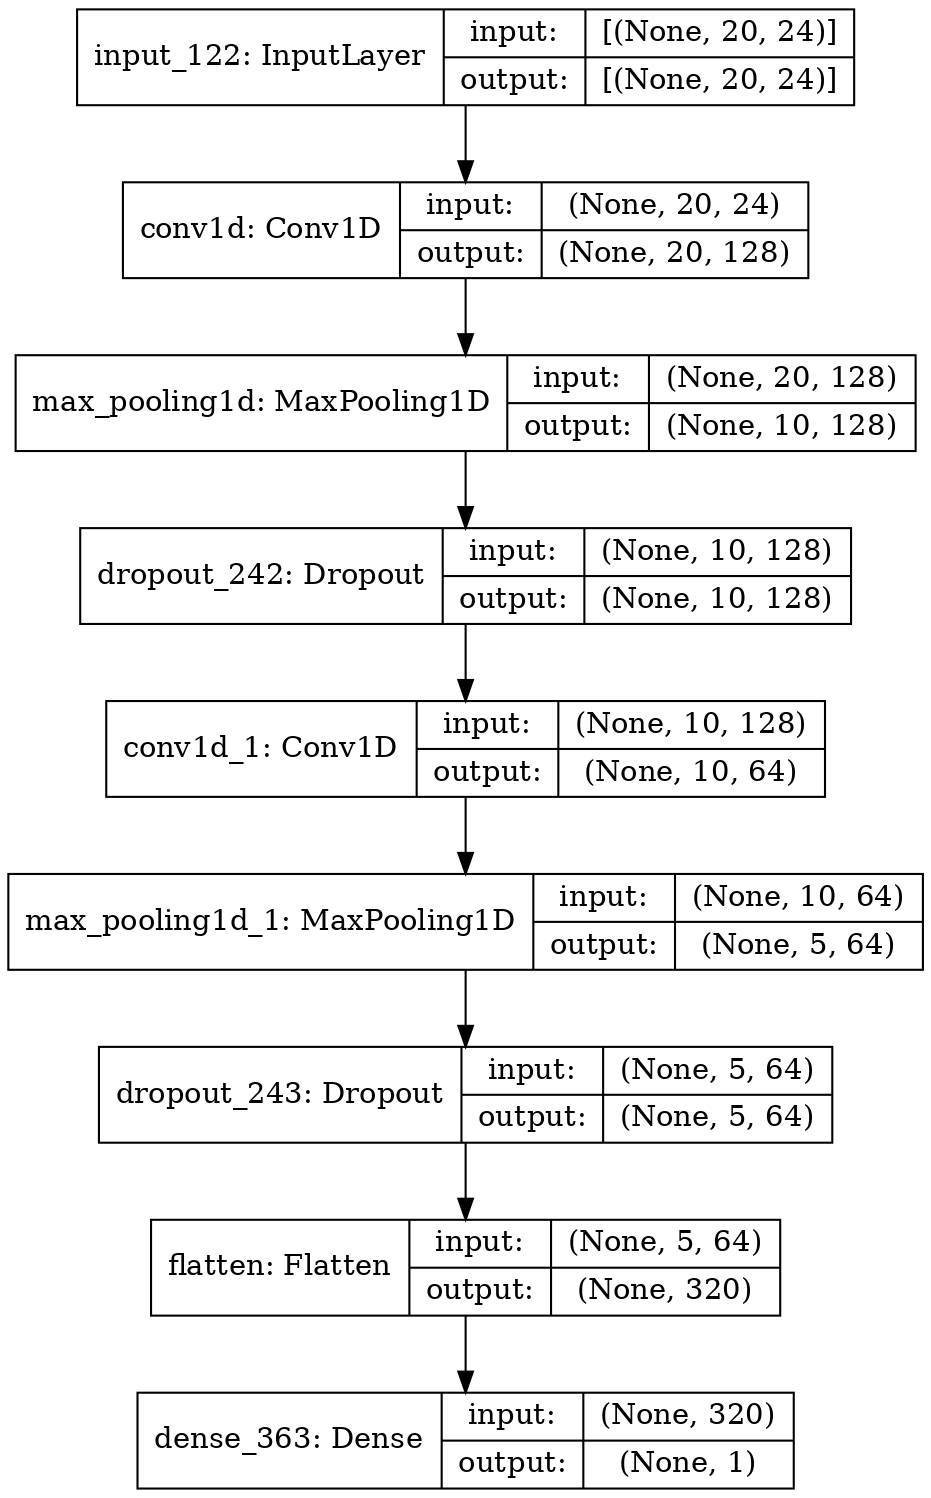

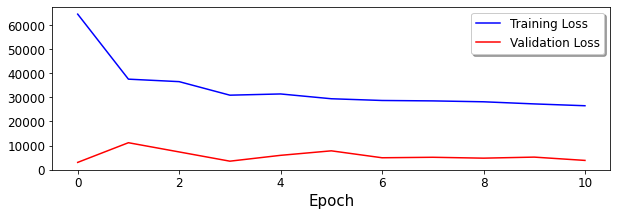

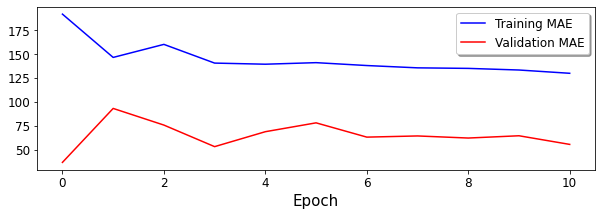

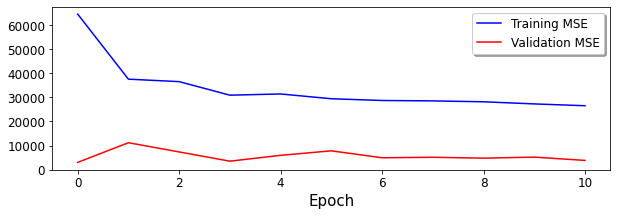

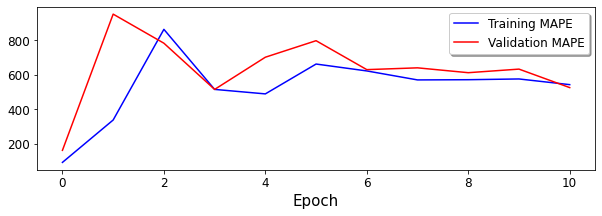

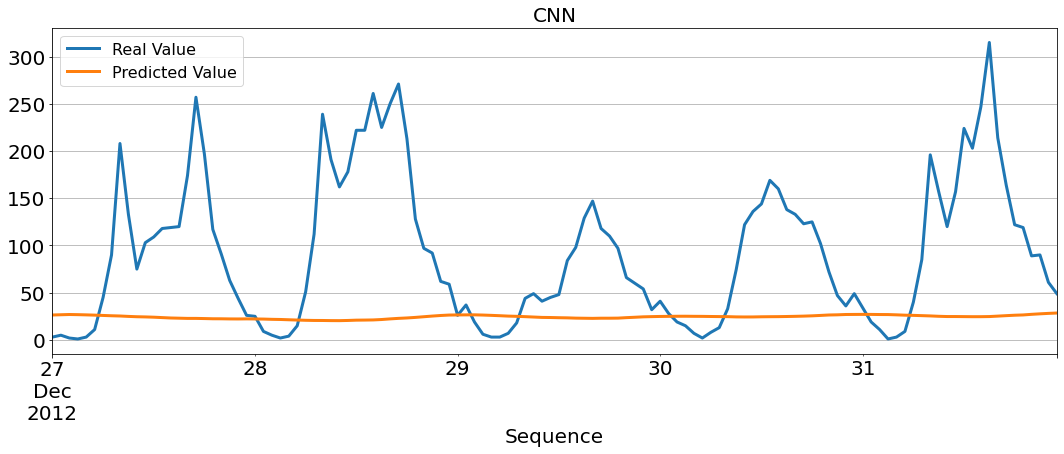

,MAE,MSE,MAPE
Score,75.91,"10,572.58",1.83


In [7]:
# Data Loading
location = os.path.join(os.getcwd(),'Data','BikeSharingDemand','Bike_Sharing_Demand_Full.csv')
df = pd.read_csv(location)

# Preprocessing
X_colname = [x for x in df.columns if x not in Y_colname+X_remove]
df = feature_engineering(df)
X_colname = [x for x in df.columns if x not in Y_colname+X_remove]
target = ['count_trend', 'count_seasonal', 'count_Day', 'count_Week', 'count_diff']
df = feature_engineering_year_duplicated(df, target)
df = df[Y_colname + X_colname].copy()
df = df[-500:].copy()

# Data Split and Scaling
X_train, Y_train, X_val, Y_val, X_test, Y_test = \
dl_preprocessing(df, Y_colname, TEST_SIZE=TEST_SIZE, SCALER=SCALER, 
                 CONVERT_SEQ=True, SEQUENCE=SEQUENCE)

# CNN
algo_CNN = dl_CNN(X_train, OUTPUT, ACTIVATION='relu', DROPOUT_RATIO=DROPOUT_RATIO)
dl_show_structure(algo_CNN, RESULT_LOCATION=RESULT_LOCATION, 
                  RESULT_NAME='CNN.png', RESULT_DPI=150)

# Learning
algo_CNN, algo_CNNfit = dl_learning_reg(algo_CNN, X_train, Y_train, X_val, Y_val,
                                        OPTIMIZER=OPTIMIZER, 
                                        BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS,
                                        CALLBACK_TYPE=CALLBACK_TYPE, EARLYSTOP_PATIENT=EARLYSTOP_PATIENT,
                                        VERBOSE=VERBOSE, 
                                        RESULT_LOCATION=RESULT_LOCATION, RESULT_NAME='CNN.h5')
evaluation_reg_LearningPlot(algo_CNNfit)

# Prediction
Y_pred = algo_CNN.predict(X_test)
Y_pred = pd.DataFrame(Y_pred, index=Y_test.index, columns=Y_colname)

# Evaluation
evaluation_reg_PredPlot(Y_test, Y_pred, title='CNN', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_test, Y_pred)
display(Score)

# Summary
Score_CNN = Score.copy()
Y_pred_CNN = Y_pred.copy()

### Walk Forward

 99%|█████████▉| 119/120 [04:19<00:02,  2.09s/it]

Model: "model_241"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_242 (InputLayer)       [(None, 20, 24)]          0         
_________________________________________________________________
conv1d_240 (Conv1D)          (None, 20, 128)           61568     
_________________________________________________________________
max_pooling1d_240 (MaxPoolin (None, 10, 128)           0         
_________________________________________________________________
dropout_482 (Dropout)        (None, 10, 128)           0         
_________________________________________________________________
conv1d_241 (Conv1D)          (None, 10, 64)            163904    
_________________________________________________________________
max_pooling1d_241 (MaxPoolin (None, 5, 64)             0         
_________________________________________________________________
dropout_483 (Dropout)        (None, 5, 64)             0 

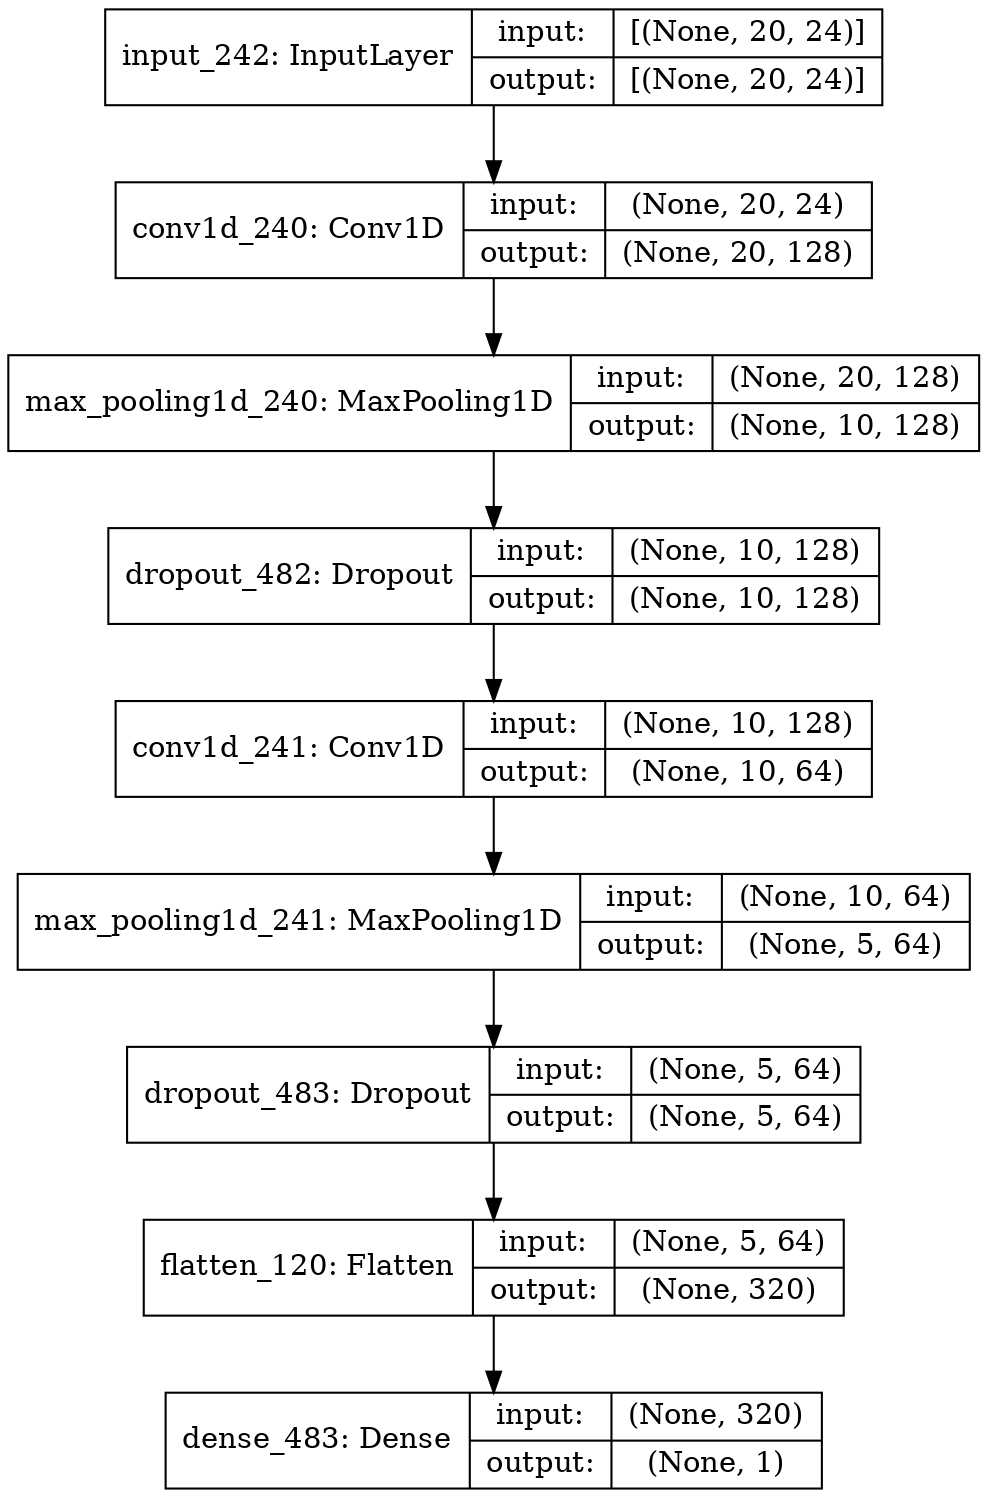

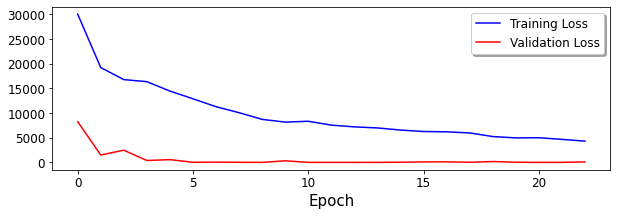

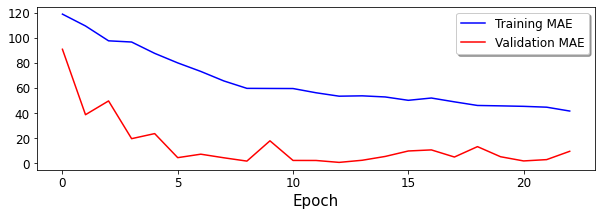

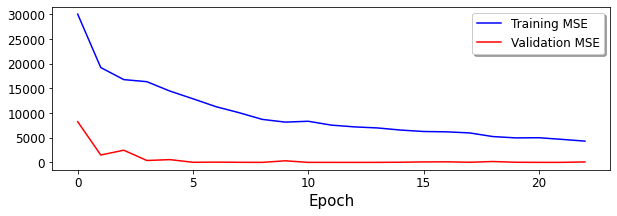

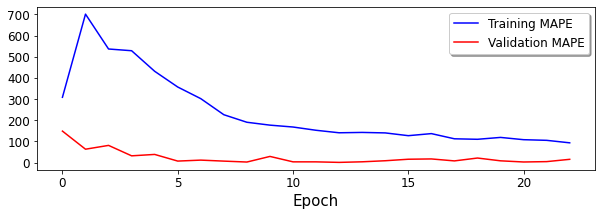

100%|██████████| 120/120 [04:22<00:00,  2.19s/it]


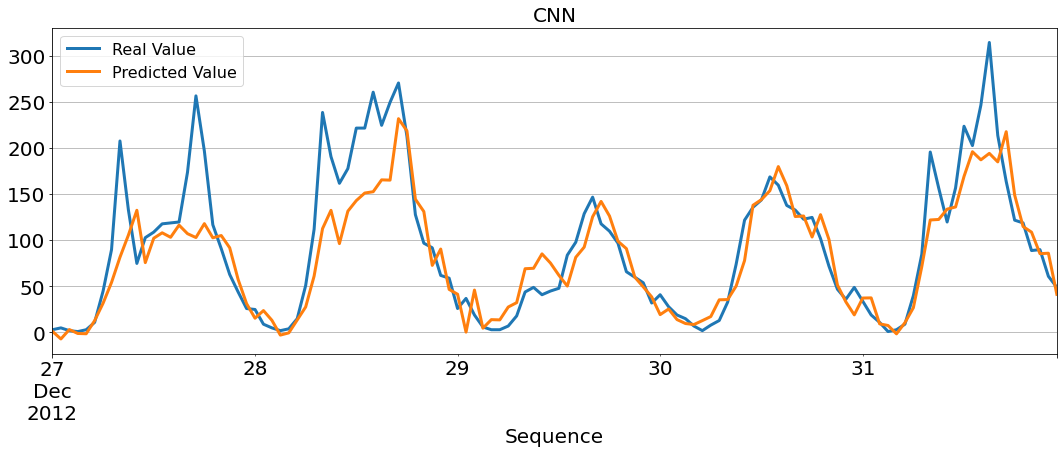

,MAE,MSE,MAPE
Score,25.84,"1,502.18",0.59


In [8]:
# Data Loading
location = os.path.join(os.getcwd(),'Data','BikeSharingDemand','Bike_Sharing_Demand_Full.csv')
df = pd.read_csv(location)

# Preprocessing
X_colname = [x for x in df.columns if x not in Y_colname+X_remove]
df = feature_engineering(df)
X_colname = [x for x in df.columns if x not in Y_colname+X_remove]
target = ['count_trend', 'count_seasonal', 'count_Day', 'count_Week', 'count_diff']
df = feature_engineering_year_duplicated(df, target)
df = df[Y_colname + X_colname].copy()
df = df[-500:].copy()

# Modeling
Y_real, Y_pred = pd.DataFrame(), pd.DataFrame()
spliter = TimeSeriesSplit(gap=0, n_splits=TEST_SIZE, test_size=OUTPUT)
for idx, (train_index, test_index) in tqdm(enumerate(spliter.split(df)), total=TEST_SIZE):
    # Data Split and Scaling
    X_train, Y_train, X_val, Y_val, X_test, Y_test = \
    dl_preprocessing_walkforward(df, Y_colname, train_index, test_index, 
                                 VAL_SIZE=OUTPUT, SCALER=SCALER, 
                                 CONVERT_SEQ=True, SEQUENCE=SEQUENCE)
    
    # CNN
    algo_CNN = dl_CNN(X_train, 1, ACTIVATION='relu', DROPOUT_RATIO=DROPOUT_RATIO)
    if (idx+1) == TEST_SIZE:
        dl_show_structure(algo_CNN, RESULT_LOCATION=RESULT_LOCATION, 
                          RESULT_NAME='CNN_Forward.png', RESULT_DPI=150)
    
    # Learning
    algo_CNN, algo_CNNfit = dl_learning_reg(algo_CNN, X_train, Y_train, X_val, Y_val,
                                            OPTIMIZER=OPTIMIZER, 
                                            BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS,
                                            CALLBACK_TYPE=CALLBACK_TYPE, EARLYSTOP_PATIENT=EARLYSTOP_PATIENT,
                                            VERBOSE=VERBOSE, 
                                            RESULT_LOCATION=RESULT_LOCATION, RESULT_NAME='CNN_Forward.h5')
    if (idx+1) == TEST_SIZE:
        evaluation_reg_LearningPlot(algo_CNNfit)
    
    # Prediction
    Y_tepred = algo_CNN.predict(X_test)
    
    # Rearrange
    Y_real = pd.concat([Y_real, Y_test], axis=0)
    Y_pred = pd.concat([Y_pred, pd.DataFrame(Y_tepred, index=Y_test.index,
                                             columns=Y_test.columns)], axis=0)
    
# Evaluation
evaluation_reg_PredPlot(Y_real, Y_pred, title='CNN', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_real, Y_pred)
display(Score)

# Summary
Score_CNN = Score.copy()
Y_pred_CNN = Y_pred.copy()

## RNN

Trasformed:
X_train: (241, 20, 24) Y_train: (241, 1)
X_val: (120, 20, 24) Y_val: (120, 1)
X_test: (120, 20, 24) Y_test: (120, 1)
Model: "model_242"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_243 (InputLayer)       [(None, 20, 24)]          0         
_________________________________________________________________
simple_rnn (SimpleRNN)       (None, 20, 128)           19584     
_________________________________________________________________
dropout_484 (Dropout)        (None, 20, 128)           0         
_________________________________________________________________
simple_rnn_1 (SimpleRNN)     (None, 20, 64)            12352     
_________________________________________________________________
dropout_485 (Dropout)        (None, 20, 64)            0         
_________________________________________________________________
flatten_121 (Flatten)        (None, 1280)              0    

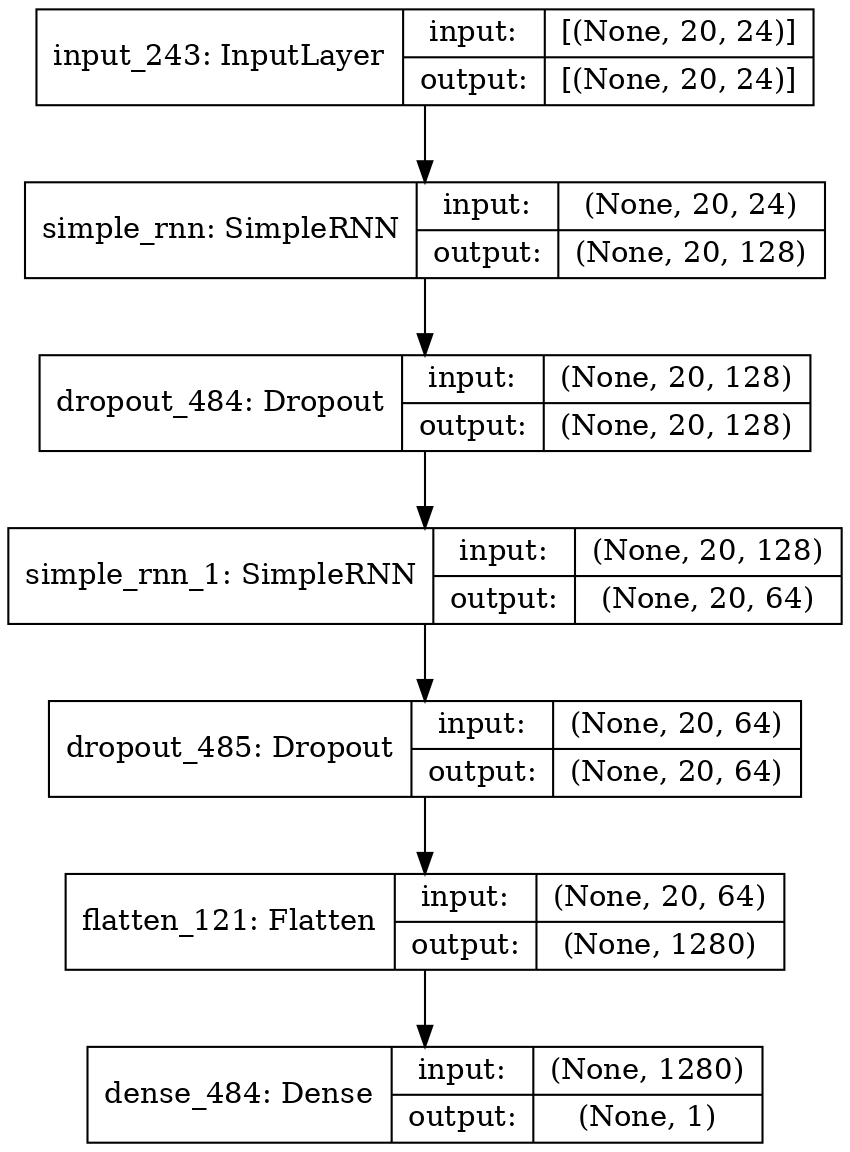

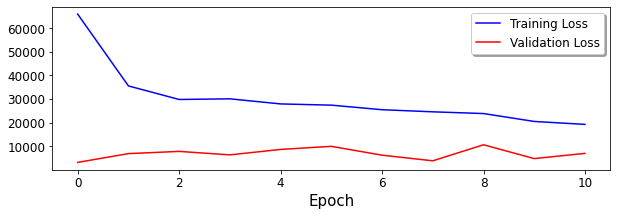

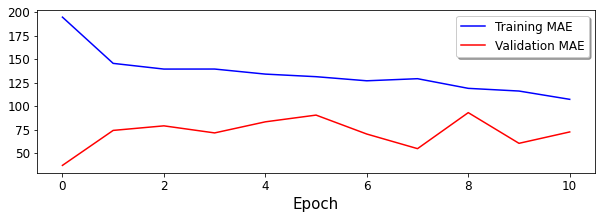

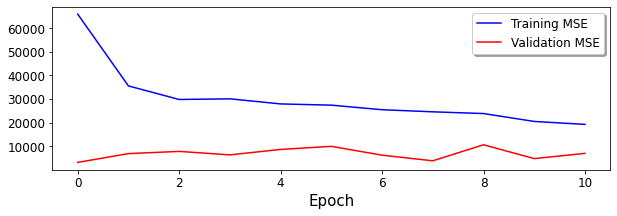

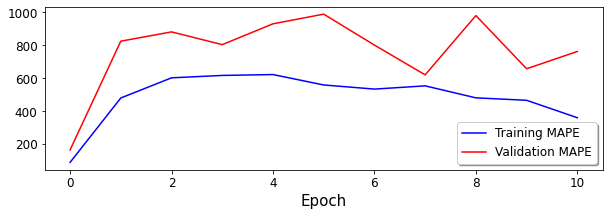

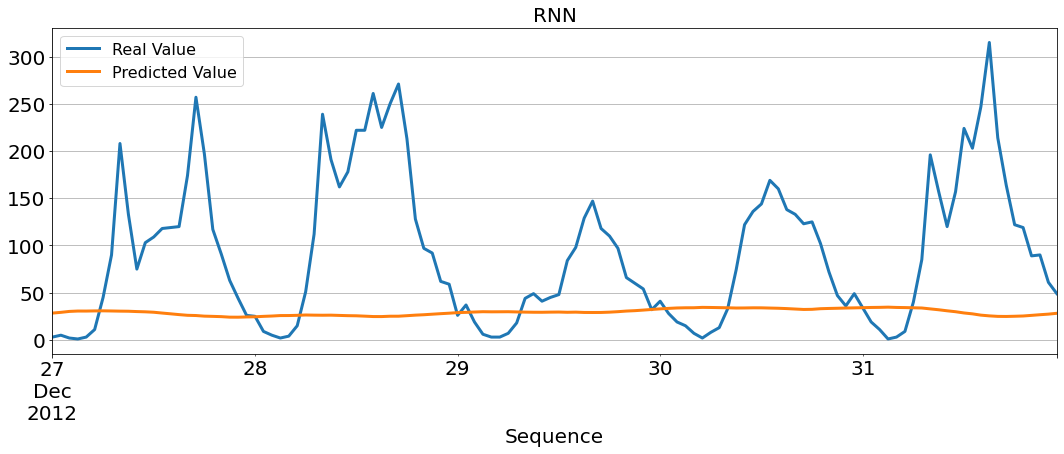

,MAE,MSE,MAPE
Score,73.70,"10,014.38",2.11


In [9]:
# Data Loading
location = os.path.join(os.getcwd(),'Data','BikeSharingDemand','Bike_Sharing_Demand_Full.csv')
df = pd.read_csv(location)

# Preprocessing
X_colname = [x for x in df.columns if x not in Y_colname+X_remove]
df = feature_engineering(df)
X_colname = [x for x in df.columns if x not in Y_colname+X_remove]
target = ['count_trend', 'count_seasonal', 'count_Day', 'count_Week', 'count_diff']
df = feature_engineering_year_duplicated(df, target)
df = df[Y_colname + X_colname].copy()
df = df[-500:].copy()

# Data Split and Scaling
X_train, Y_train, X_val, Y_val, X_test, Y_test = \
dl_preprocessing(df, Y_colname, TEST_SIZE=TEST_SIZE, SCALER=SCALER, 
                 CONVERT_SEQ=True, SEQUENCE=SEQUENCE)

# RNN
algo_RNN = dl_RNN(X_train, OUTPUT, ACTIVATION='relu', DROPOUT_RATIO=DROPOUT_RATIO)
dl_show_structure(algo_RNN, RESULT_LOCATION=RESULT_LOCATION, 
                  RESULT_NAME='RNN.png', RESULT_DPI=150)

# Learning
algo_RNN, algo_RNNfit = dl_learning_reg(algo_RNN, X_train, Y_train, X_val, Y_val,
                                        OPTIMIZER=OPTIMIZER, 
                                        BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS,
                                        CALLBACK_TYPE=CALLBACK_TYPE, EARLYSTOP_PATIENT=EARLYSTOP_PATIENT,
                                        VERBOSE=VERBOSE, 
                                        RESULT_LOCATION=RESULT_LOCATION, RESULT_NAME='RNN.h5')
evaluation_reg_LearningPlot(algo_RNNfit)

# Prediction
Y_pred = algo_RNN.predict(X_test)
Y_pred = pd.DataFrame(Y_pred, index=Y_test.index, columns=Y_colname)

# Evaluation
evaluation_reg_PredPlot(Y_test, Y_pred, title='RNN', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_test, Y_pred)
display(Score)

# Summary
Score_RNN = Score.copy()
Y_pred_RNN = Y_pred.copy()

### Walk Forward

 99%|█████████▉| 119/120 [17:54<00:07,  7.36s/it]

Model: "model_362"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_363 (InputLayer)       [(None, 20, 24)]          0         
_________________________________________________________________
simple_rnn_240 (SimpleRNN)   (None, 20, 128)           19584     
_________________________________________________________________
dropout_724 (Dropout)        (None, 20, 128)           0         
_________________________________________________________________
simple_rnn_241 (SimpleRNN)   (None, 20, 64)            12352     
_________________________________________________________________
dropout_725 (Dropout)        (None, 20, 64)            0         
_________________________________________________________________
flatten_241 (Flatten)        (None, 1280)              0         
_________________________________________________________________
dense_604 (Dense)            (None, 1)                 12

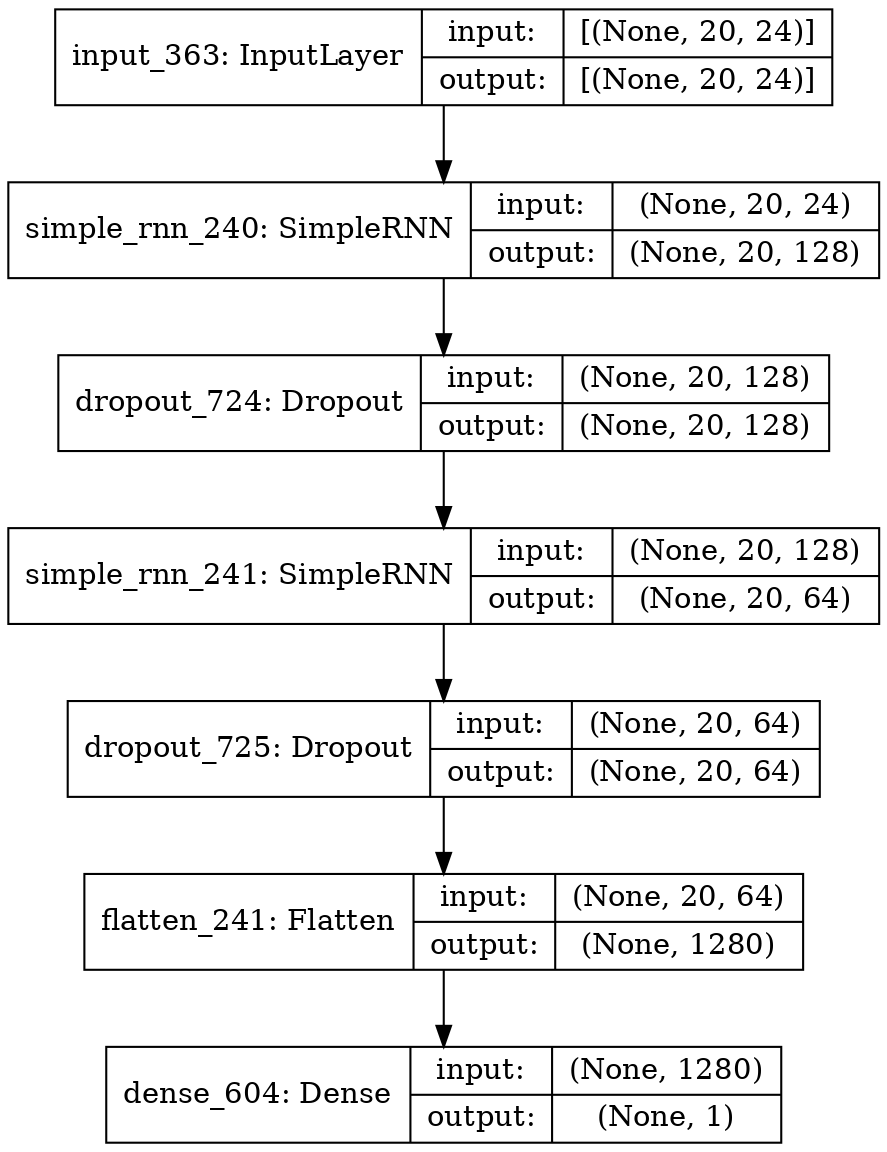

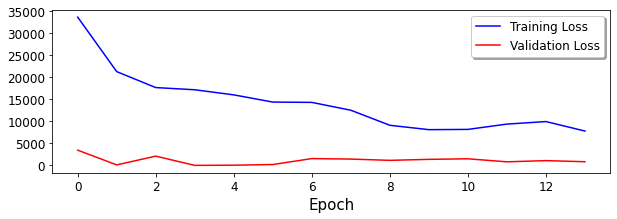

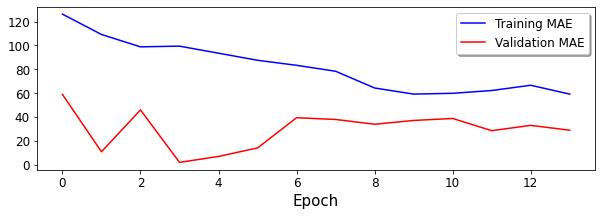

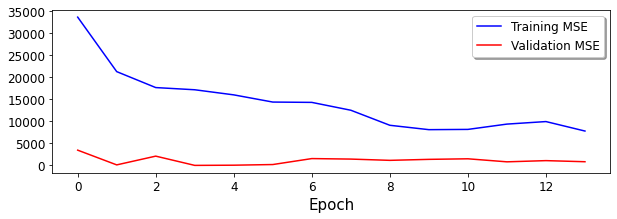

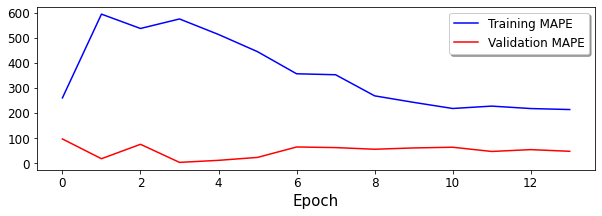

100%|██████████| 120/120 [18:01<00:00,  9.02s/it]


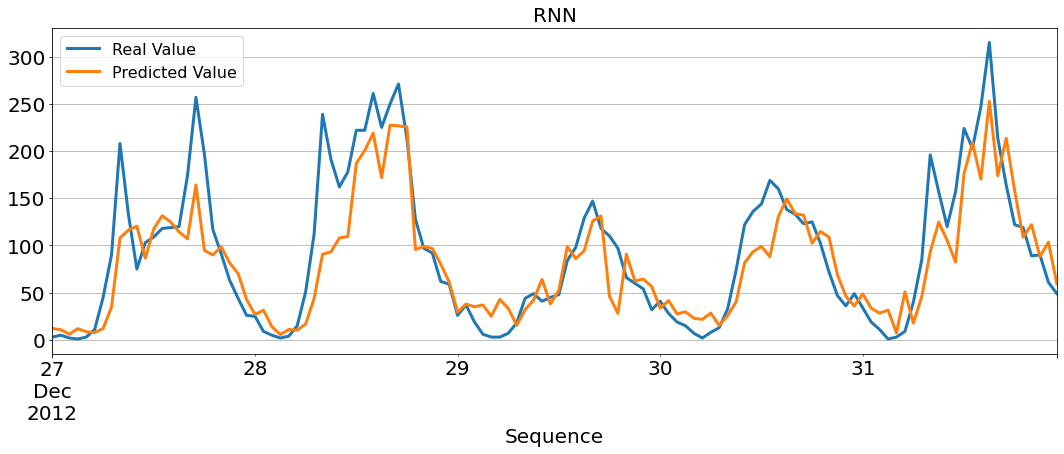

,MAE,MSE,MAPE
Score,27.84,"1,484.64",1.17


In [10]:
# Data Loading
location = os.path.join(os.getcwd(),'Data','BikeSharingDemand','Bike_Sharing_Demand_Full.csv')
df = pd.read_csv(location)

# Preprocessing
X_colname = [x for x in df.columns if x not in Y_colname+X_remove]
df = feature_engineering(df)
X_colname = [x for x in df.columns if x not in Y_colname+X_remove]
target = ['count_trend', 'count_seasonal', 'count_Day', 'count_Week', 'count_diff']
df = feature_engineering_year_duplicated(df, target)
df = df[Y_colname + X_colname].copy()
df = df[-500:].copy()

# Modeling
Y_real, Y_pred = pd.DataFrame(), pd.DataFrame()
spliter = TimeSeriesSplit(gap=0, n_splits=TEST_SIZE, test_size=OUTPUT)
for idx, (train_index, test_index) in tqdm(enumerate(spliter.split(df)), total=TEST_SIZE):
    # Data Split and Scaling
    X_train, Y_train, X_val, Y_val, X_test, Y_test = \
    dl_preprocessing_walkforward(df, Y_colname, train_index, test_index, 
                                 VAL_SIZE=OUTPUT, SCALER=SCALER, 
                                 CONVERT_SEQ=True, SEQUENCE=SEQUENCE)
    
    # RNN
    algo_RNN = dl_RNN(X_train, 1, ACTIVATION='relu', DROPOUT_RATIO=DROPOUT_RATIO)
    if (idx+1) == TEST_SIZE:
        dl_show_structure(algo_RNN, RESULT_LOCATION=RESULT_LOCATION, 
                          RESULT_NAME='RNN_Forward.png', RESULT_DPI=150)
    
    # Learning
    algo_RNN, algo_RNNfit = dl_learning_reg(algo_RNN, X_train, Y_train, X_val, Y_val,
                                            OPTIMIZER=OPTIMIZER, 
                                            BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS,
                                            CALLBACK_TYPE=CALLBACK_TYPE, EARLYSTOP_PATIENT=EARLYSTOP_PATIENT,
                                            VERBOSE=VERBOSE, 
                                            RESULT_LOCATION=RESULT_LOCATION, RESULT_NAME='RNN_Forward.h5')
    if (idx+1) == TEST_SIZE:
        evaluation_reg_LearningPlot(algo_RNNfit)
    
    # Prediction
    Y_tepred = algo_RNN.predict(X_test)
    
    # Rearrange
    Y_real = pd.concat([Y_real, Y_test], axis=0)
    Y_pred = pd.concat([Y_pred, pd.DataFrame(Y_tepred, index=Y_test.index,
                                             columns=Y_test.columns)], axis=0)
    
# Evaluation
evaluation_reg_PredPlot(Y_real, Y_pred, title='RNN', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_real, Y_pred)
display(Score)

# Summary
Score_RNN = Score.copy()
Y_pred_RNN = Y_pred.copy()

## LSTM

Trasformed:
X_train: (241, 20, 24) Y_train: (241, 1)
X_val: (120, 20, 24) Y_val: (120, 1)
X_test: (120, 20, 24) Y_test: (120, 1)
Model: "model_363"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_364 (InputLayer)       [(None, 20, 24)]          0         
_________________________________________________________________
lstm (LSTM)                  (None, 20, 128)           78336     
_________________________________________________________________
dropout_726 (Dropout)        (None, 20, 128)           0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 64)                49408     
_________________________________________________________________
dropout_727 (Dropout)        (None, 64)                0         
_________________________________________________________________
dense_605 (Dense)            (None, 1)                 65   

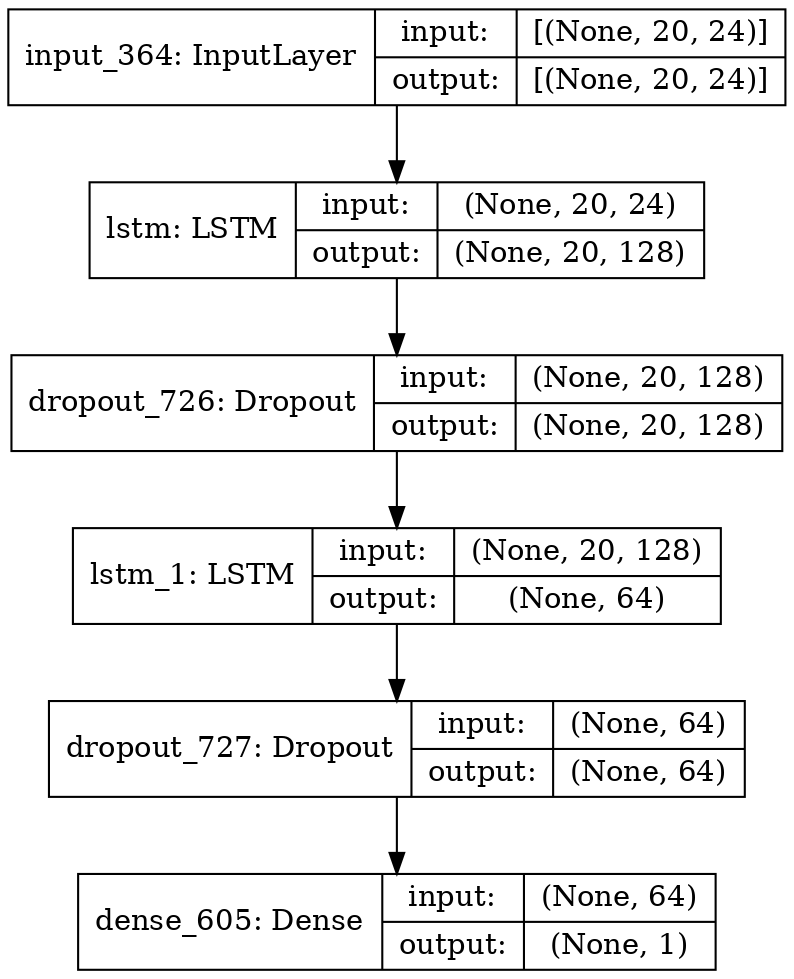

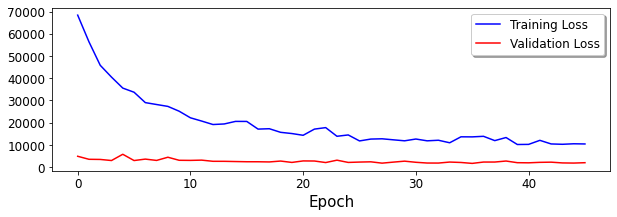

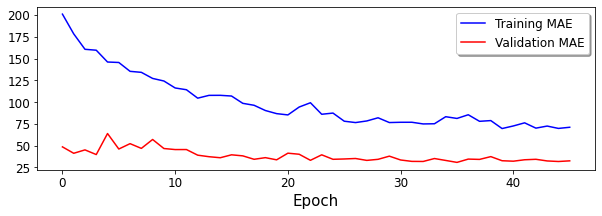

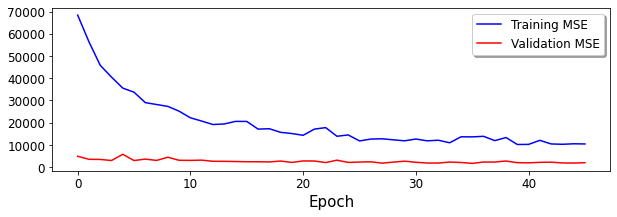

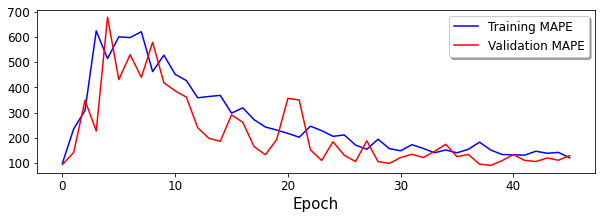

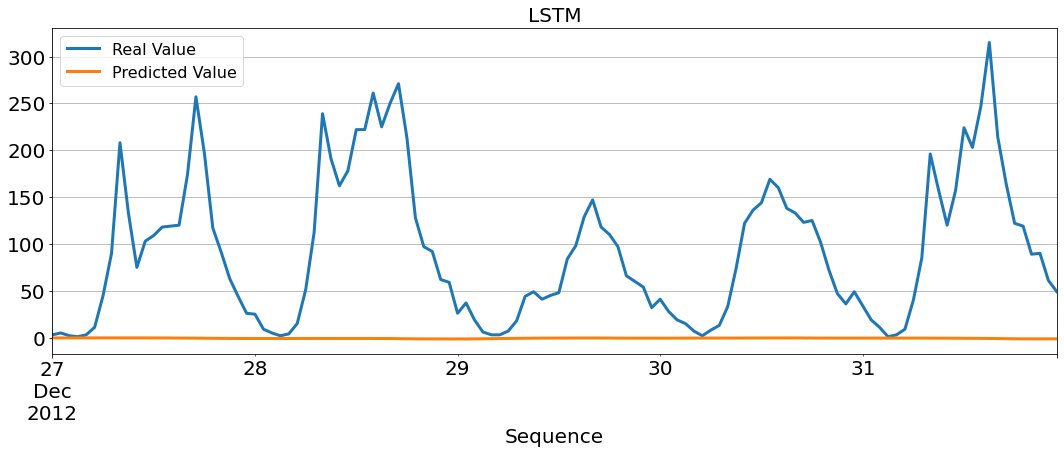

,MAE,MSE,MAPE
Score,92.98,"14,500.52",1.04


In [11]:
# Data Loading
location = os.path.join(os.getcwd(),'Data','BikeSharingDemand','Bike_Sharing_Demand_Full.csv')
df = pd.read_csv(location)

# Preprocessing
X_colname = [x for x in df.columns if x not in Y_colname+X_remove]
df = feature_engineering(df)
X_colname = [x for x in df.columns if x not in Y_colname+X_remove]
target = ['count_trend', 'count_seasonal', 'count_Day', 'count_Week', 'count_diff']
df = feature_engineering_year_duplicated(df, target)
df = df[Y_colname + X_colname].copy()
df = df[-500:].copy()

# Data Split and Scaling
X_train, Y_train, X_val, Y_val, X_test, Y_test = \
dl_preprocessing(df, Y_colname, TEST_SIZE=TEST_SIZE, SCALER=SCALER, 
                 CONVERT_SEQ=True, SEQUENCE=SEQUENCE)

# LSTM
algo_LSTM = dl_LSTM(X_train, OUTPUT, ACTIVATION='relu', DROPOUT_RATIO=DROPOUT_RATIO)
dl_show_structure(algo_LSTM, RESULT_LOCATION=RESULT_LOCATION, 
                  RESULT_NAME='LSTM.png', RESULT_DPI=150)

# Learning
algo_LSTM, algo_LSTMfit = dl_learning_reg(algo_LSTM, X_train, Y_train, X_val, Y_val,
                                        OPTIMIZER=OPTIMIZER, 
                                        BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS,
                                        CALLBACK_TYPE=CALLBACK_TYPE, EARLYSTOP_PATIENT=EARLYSTOP_PATIENT,
                                        VERBOSE=VERBOSE, 
                                        RESULT_LOCATION=RESULT_LOCATION, RESULT_NAME='LSTM.h5')
evaluation_reg_LearningPlot(algo_LSTMfit)

# Prediction
Y_pred = algo_LSTM.predict(X_test)
Y_pred = pd.DataFrame(Y_pred, index=Y_test.index, columns=Y_colname)

# Evaluation
evaluation_reg_PredPlot(Y_test, Y_pred, title='LSTM', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_test, Y_pred)
display(Score)

# Summary
Score_LSTM = Score.copy()
Y_pred_LSTM = Y_pred.copy()

### Walk Forward

 99%|█████████▉| 119/120 [33:24<00:16, 16.56s/it]

Model: "model_483"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_484 (InputLayer)       [(None, 20, 24)]          0         
_________________________________________________________________
lstm_240 (LSTM)              (None, 20, 128)           78336     
_________________________________________________________________
dropout_966 (Dropout)        (None, 20, 128)           0         
_________________________________________________________________
lstm_241 (LSTM)              (None, 64)                49408     
_________________________________________________________________
dropout_967 (Dropout)        (None, 64)                0         
_________________________________________________________________
dense_725 (Dense)            (None, 1)                 65        
Total params: 127,809
Trainable params: 127,809
Non-trainable params: 0
___________________________________________________

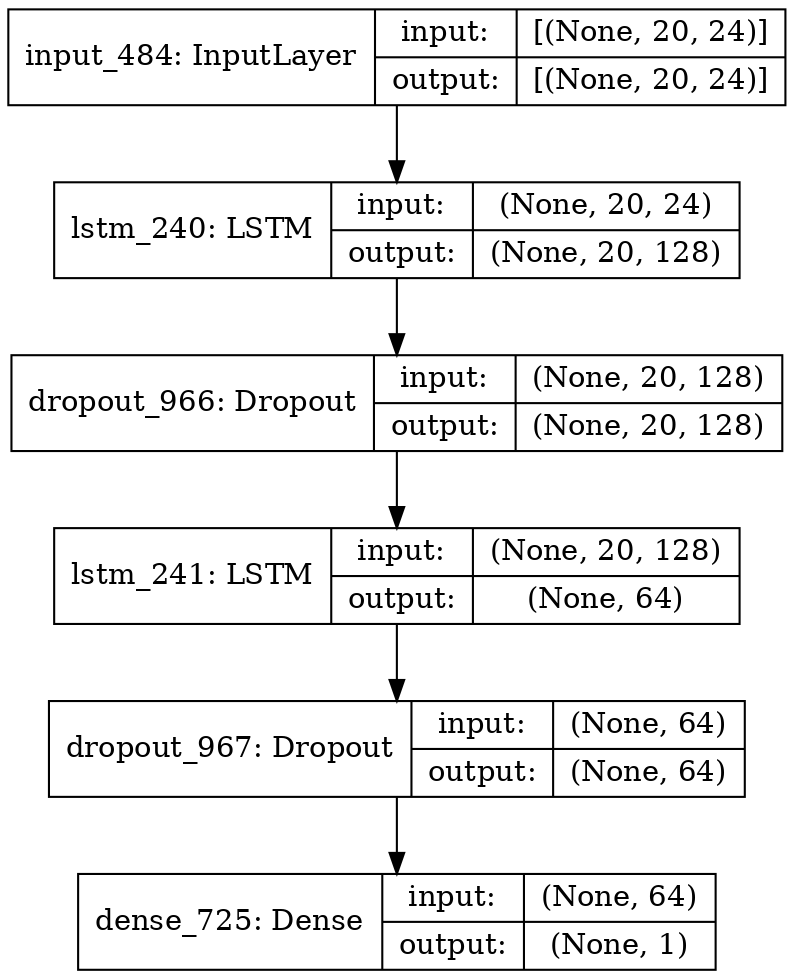

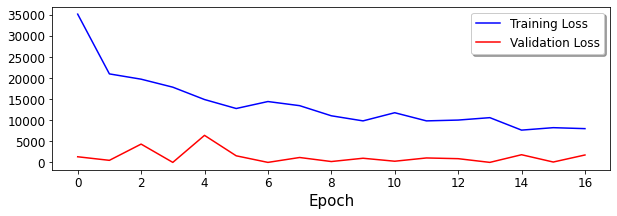

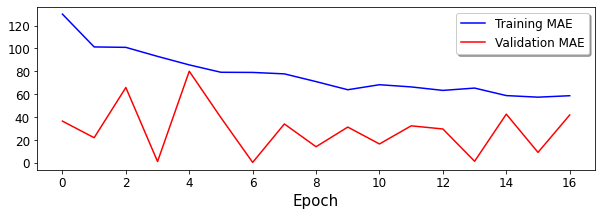

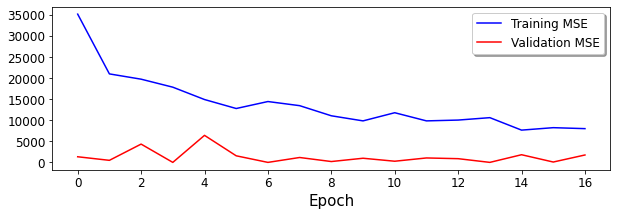

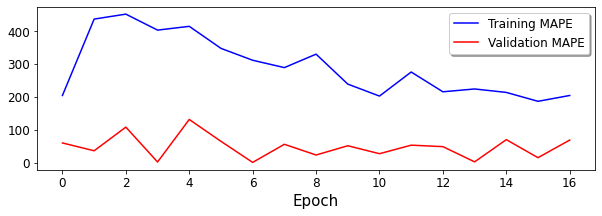

100%|██████████| 120/120 [33:39<00:00, 16.83s/it]


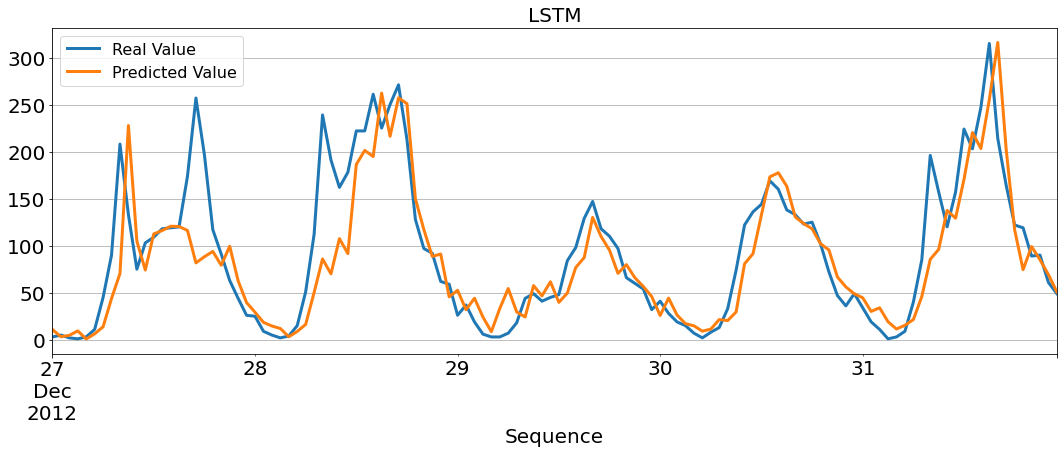

,MAE,MSE,MAPE
Score,27.05,"1,751.13",0.86


In [12]:
# Data Loading
location = os.path.join(os.getcwd(),'Data','BikeSharingDemand','Bike_Sharing_Demand_Full.csv')
df = pd.read_csv(location)

# Preprocessing
X_colname = [x for x in df.columns if x not in Y_colname+X_remove]
df = feature_engineering(df)
X_colname = [x for x in df.columns if x not in Y_colname+X_remove]
target = ['count_trend', 'count_seasonal', 'count_Day', 'count_Week', 'count_diff']
df = feature_engineering_year_duplicated(df, target)
df = df[Y_colname + X_colname].copy()
df = df[-500:].copy()

# Modeling
Y_real, Y_pred = pd.DataFrame(), pd.DataFrame()
spliter = TimeSeriesSplit(gap=0, n_splits=TEST_SIZE, test_size=OUTPUT)
for idx, (train_index, test_index) in tqdm(enumerate(spliter.split(df)), total=TEST_SIZE):
    # Data Split and Scaling
    X_train, Y_train, X_val, Y_val, X_test, Y_test = \
    dl_preprocessing_walkforward(df, Y_colname, train_index, test_index, 
                                 VAL_SIZE=OUTPUT, SCALER=SCALER, 
                                 CONVERT_SEQ=True, SEQUENCE=SEQUENCE)
    
    # LSTM
    algo_LSTM = dl_LSTM(X_train, 1, ACTIVATION='relu', DROPOUT_RATIO=DROPOUT_RATIO)
    if (idx+1) == TEST_SIZE:
        dl_show_structure(algo_LSTM, RESULT_LOCATION=RESULT_LOCATION, 
                          RESULT_NAME='LSTM_Forward.png', RESULT_DPI=150)
    
    # Learning
    algo_LSTM, algo_LSTMfit = dl_learning_reg(algo_LSTM, X_train, Y_train, X_val, Y_val,
                                              OPTIMIZER=OPTIMIZER, 
                                              BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS,
                                              CALLBACK_TYPE=CALLBACK_TYPE, EARLYSTOP_PATIENT=EARLYSTOP_PATIENT,
                                              VERBOSE=VERBOSE, 
                                              RESULT_LOCATION=RESULT_LOCATION, RESULT_NAME='LSTM_Forward.h5')
    if (idx+1) == TEST_SIZE:
        evaluation_reg_LearningPlot(algo_LSTMfit)
    
    # Prediction
    Y_tepred = algo_LSTM.predict(X_test)
    
    # Rearrange
    Y_real = pd.concat([Y_real, Y_test], axis=0)
    Y_pred = pd.concat([Y_pred, pd.DataFrame(Y_tepred, index=Y_test.index,
                                             columns=Y_test.columns)], axis=0)
    
# Evaluation
evaluation_reg_PredPlot(Y_real, Y_pred, title='LSTM', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_real, Y_pred)
display(Score)

# Summary
Score_LSTM = Score.copy()
Y_pred_LSTM = Y_pred.copy()

## GRU

Trasformed:
X_train: (241, 20, 24) Y_train: (241, 1)
X_val: (120, 20, 24) Y_val: (120, 1)
X_test: (120, 20, 24) Y_test: (120, 1)
Model: "model_484"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_485 (InputLayer)       [(None, 20, 24)]          0         
_________________________________________________________________
gru (GRU)                    (None, 20, 128)           59136     
_________________________________________________________________
dropout_968 (Dropout)        (None, 20, 128)           0         
_________________________________________________________________
gru_1 (GRU)                  (None, 64)                37248     
_________________________________________________________________
dropout_969 (Dropout)        (None, 64)                0         
_________________________________________________________________
dense_726 (Dense)            (None, 1)                 65   

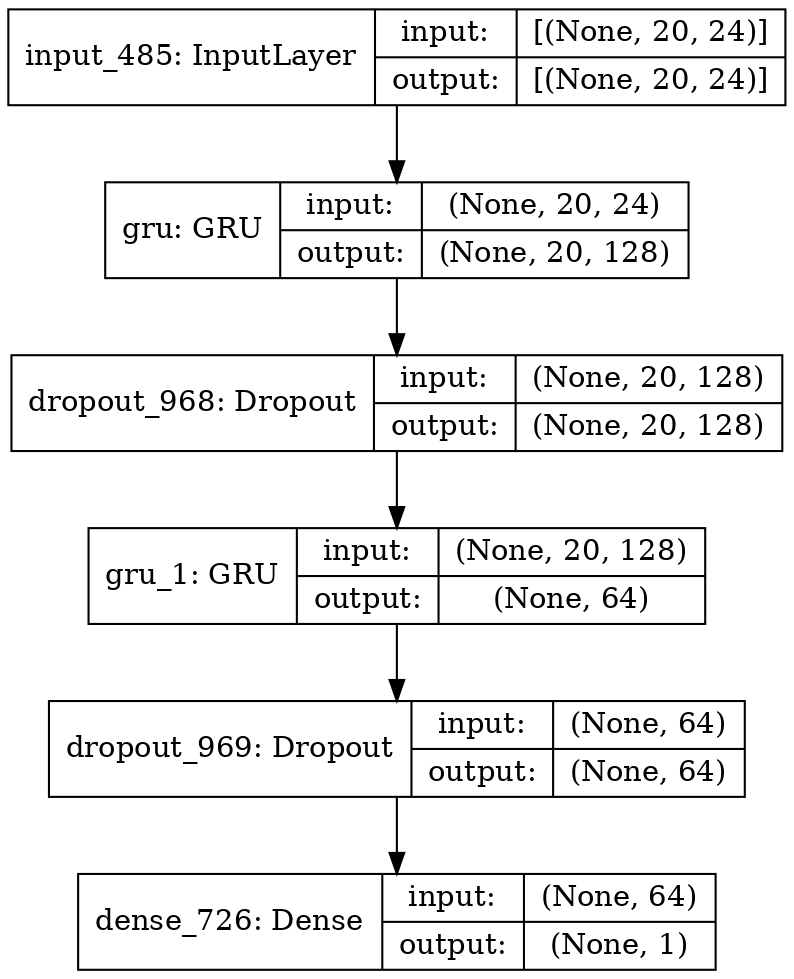

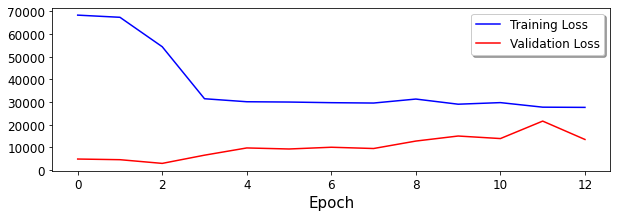

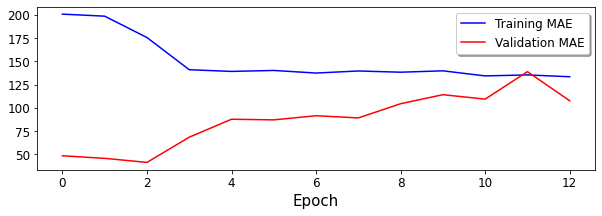

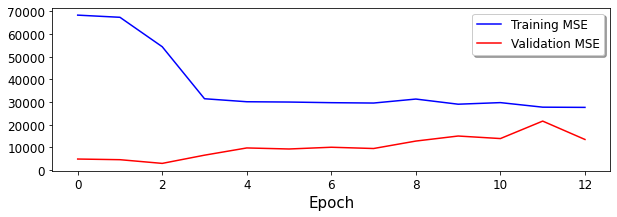

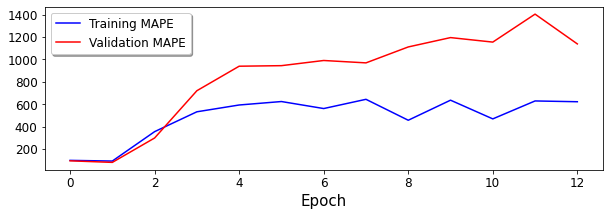

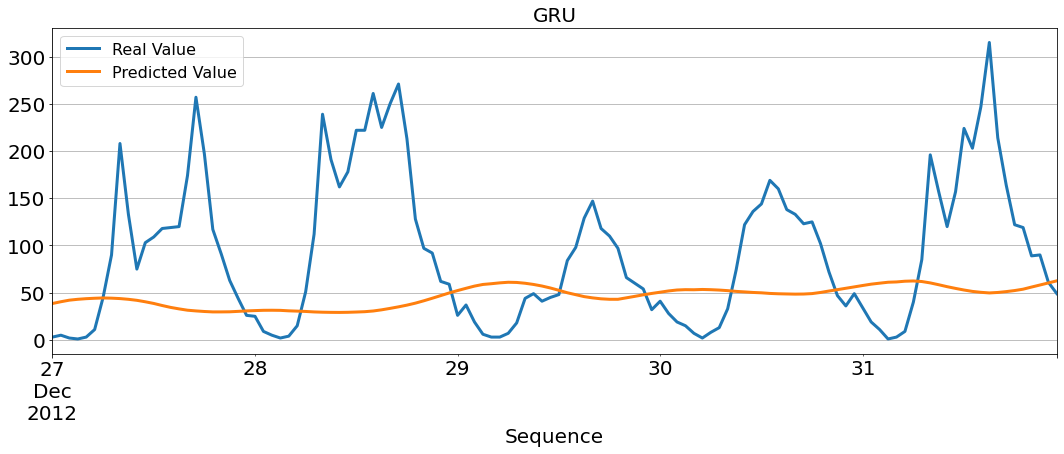

,MAE,MSE,MAPE
Score,69.92,"8,617.09",3.13


In [13]:
# Data Loading
location = os.path.join(os.getcwd(),'Data','BikeSharingDemand','Bike_Sharing_Demand_Full.csv')
df = pd.read_csv(location)

# Preprocessing
X_colname = [x for x in df.columns if x not in Y_colname+X_remove]
df = feature_engineering(df)
X_colname = [x for x in df.columns if x not in Y_colname+X_remove]
target = ['count_trend', 'count_seasonal', 'count_Day', 'count_Week', 'count_diff']
df = feature_engineering_year_duplicated(df, target)
df = df[Y_colname + X_colname].copy()
df = df[-500:].copy()

# Data Split and Scaling
X_train, Y_train, X_val, Y_val, X_test, Y_test = \
dl_preprocessing(df, Y_colname, TEST_SIZE=TEST_SIZE, SCALER=SCALER, 
                 CONVERT_SEQ=True, SEQUENCE=SEQUENCE)

# GRU
algo_GRU = dl_GRU(X_train, OUTPUT, ACTIVATION='relu', DROPOUT_RATIO=DROPOUT_RATIO)
dl_show_structure(algo_GRU, RESULT_LOCATION=RESULT_LOCATION, 
                  RESULT_NAME='GRU.png', RESULT_DPI=150)

# Learning
algo_GRU, algo_GRUfit = dl_learning_reg(algo_GRU, X_train, Y_train, X_val, Y_val,
                                        OPTIMIZER=OPTIMIZER, 
                                        BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS,
                                        CALLBACK_TYPE=CALLBACK_TYPE, EARLYSTOP_PATIENT=EARLYSTOP_PATIENT,
                                        VERBOSE=VERBOSE, 
                                        RESULT_LOCATION=RESULT_LOCATION, RESULT_NAME='GRU.h5')
evaluation_reg_LearningPlot(algo_GRUfit)

# Prediction
Y_pred = algo_GRU.predict(X_test)
Y_pred = pd.DataFrame(Y_pred, index=Y_test.index, columns=Y_colname)

# Evaluation
evaluation_reg_PredPlot(Y_test, Y_pred, title='GRU', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_test, Y_pred)
display(Score)

# Summary
Score_GRU = Score.copy()
Y_pred_GRU = Y_pred.copy()

### Walk Forward

 99%|█████████▉| 119/120 [33:43<00:20, 20.49s/it]

Model: "model_604"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_605 (InputLayer)       [(None, 20, 24)]          0         
_________________________________________________________________
gru_240 (GRU)                (None, 20, 128)           59136     
_________________________________________________________________
dropout_1208 (Dropout)       (None, 20, 128)           0         
_________________________________________________________________
gru_241 (GRU)                (None, 64)                37248     
_________________________________________________________________
dropout_1209 (Dropout)       (None, 64)                0         
_________________________________________________________________
dense_846 (Dense)            (None, 1)                 65        
Total params: 96,449
Trainable params: 96,449
Non-trainable params: 0
_____________________________________________________

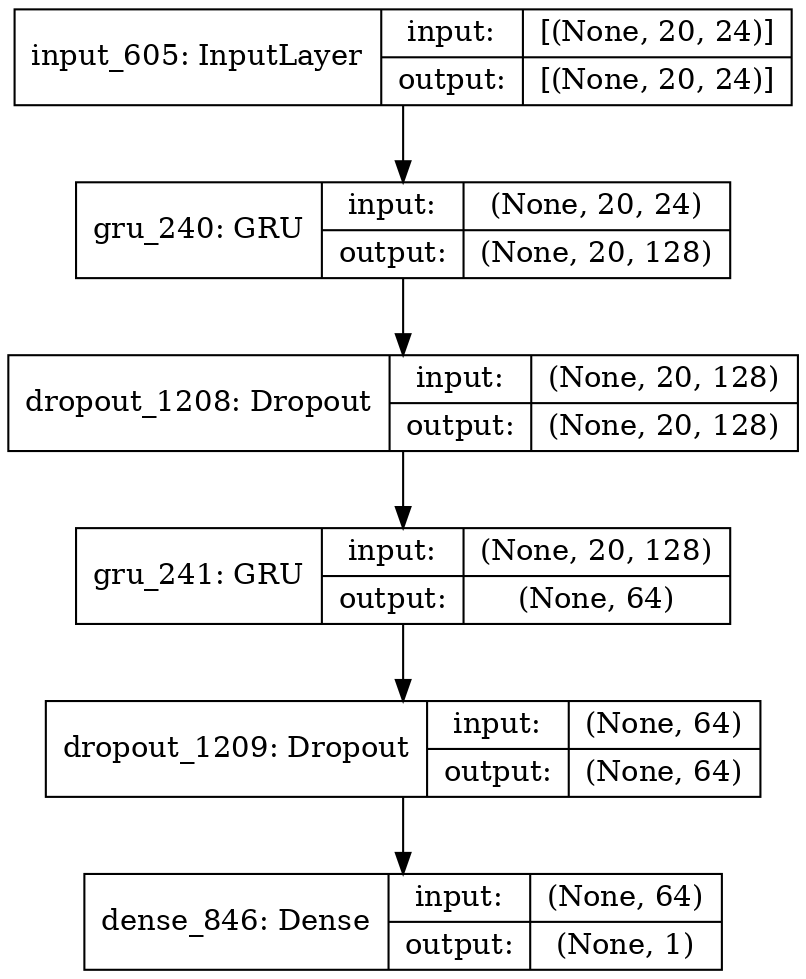

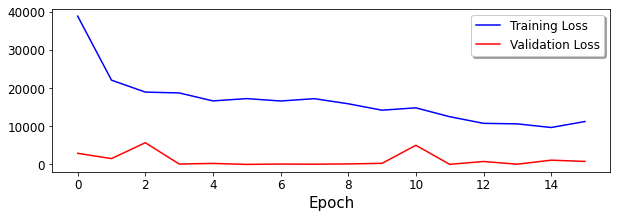

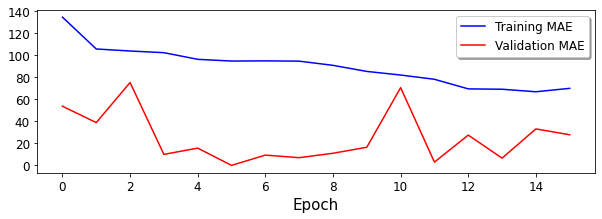

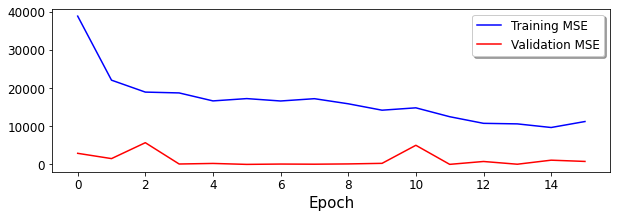

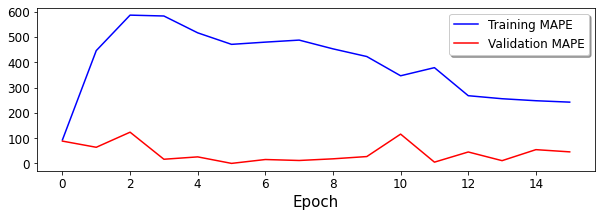

100%|██████████| 120/120 [34:01<00:00, 17.01s/it]


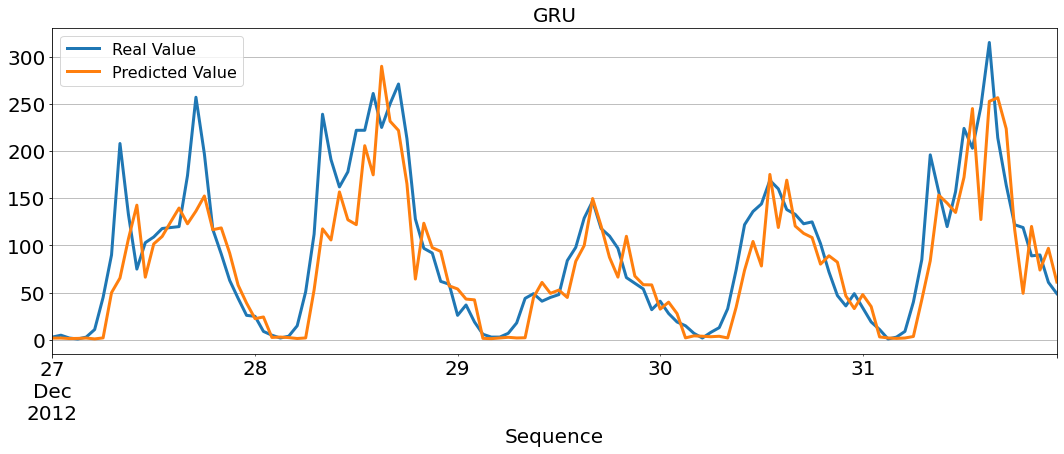

,MAE,MSE,MAPE
Score,27.89,"1,629.64",0.42


In [14]:
# Data Loading
location = os.path.join(os.getcwd(),'Data','BikeSharingDemand','Bike_Sharing_Demand_Full.csv')
df = pd.read_csv(location)

# Preprocessing
X_colname = [x for x in df.columns if x not in Y_colname+X_remove]
df = feature_engineering(df)
X_colname = [x for x in df.columns if x not in Y_colname+X_remove]
target = ['count_trend', 'count_seasonal', 'count_Day', 'count_Week', 'count_diff']
df = feature_engineering_year_duplicated(df, target)
df = df[Y_colname + X_colname].copy()
df = df[-500:].copy()

# Modeling
Y_real, Y_pred = pd.DataFrame(), pd.DataFrame()
spliter = TimeSeriesSplit(gap=0, n_splits=TEST_SIZE, test_size=OUTPUT)
for idx, (train_index, test_index) in tqdm(enumerate(spliter.split(df)), total=TEST_SIZE):
    # Data Split and Scaling
    X_train, Y_train, X_val, Y_val, X_test, Y_test = \
    dl_preprocessing_walkforward(df, Y_colname, train_index, test_index, 
                                 VAL_SIZE=OUTPUT, SCALER=SCALER, 
                                 CONVERT_SEQ=True, SEQUENCE=SEQUENCE)
    
    # GRU
    algo_GRU = dl_GRU(X_train, 1, ACTIVATION='relu', DROPOUT_RATIO=DROPOUT_RATIO)
    if (idx+1) == TEST_SIZE:
        dl_show_structure(algo_GRU, RESULT_LOCATION=RESULT_LOCATION, 
                          RESULT_NAME='GRU_Forward.png', RESULT_DPI=150)
    
    # Learning
    algo_GRU, algo_GRUfit = dl_learning_reg(algo_GRU, X_train, Y_train, X_val, Y_val,
                                            OPTIMIZER=OPTIMIZER, 
                                            BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS,
                                            CALLBACK_TYPE=CALLBACK_TYPE, EARLYSTOP_PATIENT=EARLYSTOP_PATIENT,
                                            VERBOSE=VERBOSE, 
                                            RESULT_LOCATION=RESULT_LOCATION, RESULT_NAME='GRU_Forward.h5')
    if (idx+1) == TEST_SIZE:
        evaluation_reg_LearningPlot(algo_GRUfit)
    
    # Prediction
    Y_tepred = algo_GRU.predict(X_test)
    
    # Rearrange
    Y_real = pd.concat([Y_real, Y_test], axis=0)
    Y_pred = pd.concat([Y_pred, pd.DataFrame(Y_tepred, index=Y_test.index,
                                             columns=Y_test.columns)], axis=0)
    
# Evaluation
evaluation_reg_PredPlot(Y_real, Y_pred, title='GRU', ylabel='')
Score, Resid_te = evaluation_reg_MAE_MSE_MAPE(Y_real, Y_pred)
display(Score)

# Summary
Score_GRU = Score.copy()
Y_pred_GRU = Y_pred.copy()

# Result Summary

In [15]:
Score_Final = pd.concat([Score_MLP, Score_CNN, Score_RNN, Score_LSTM, Score_GRU], axis=0)
Score_Final.index = ALGO_NAMES
Score_Final

,MAE,MSE,MAPE
MLP,26.12,"1,530.15",0.48
CNN,25.84,"1,502.18",0.59
RNN,27.84,"1,484.64",1.17
LSTM,27.05,"1,751.13",0.86
GRU,27.89,"1,629.64",0.42


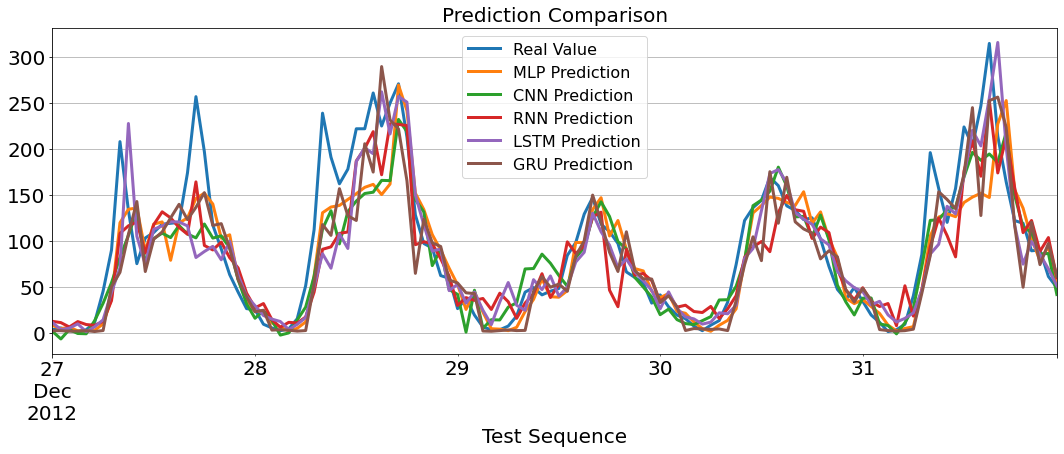

In [16]:
Y_pred_Final = pd.concat([Y_real, Y_pred_MLP, Y_pred_CNN, Y_pred_RNN, Y_pred_LSTM, Y_pred_GRU], axis=1)
Y_pred_Final.columns = ['Real Value']+[i+' Prediction' for i in ALGO_NAMES]
Y_pred_Final.plot(kind='line', figsize=(18,6), linewidth=3, fontsize=20,
                  xlim=(Y_pred_Final.index.min(),Y_pred_Final.index.max()))
plt.title('Prediction Comparison', fontsize=20)
plt.xlabel('Test Sequence', fontsize=20)
plt.ylabel('', fontsize=20)
plt.legend(fontsize=16)
plt.grid()
plt.show()

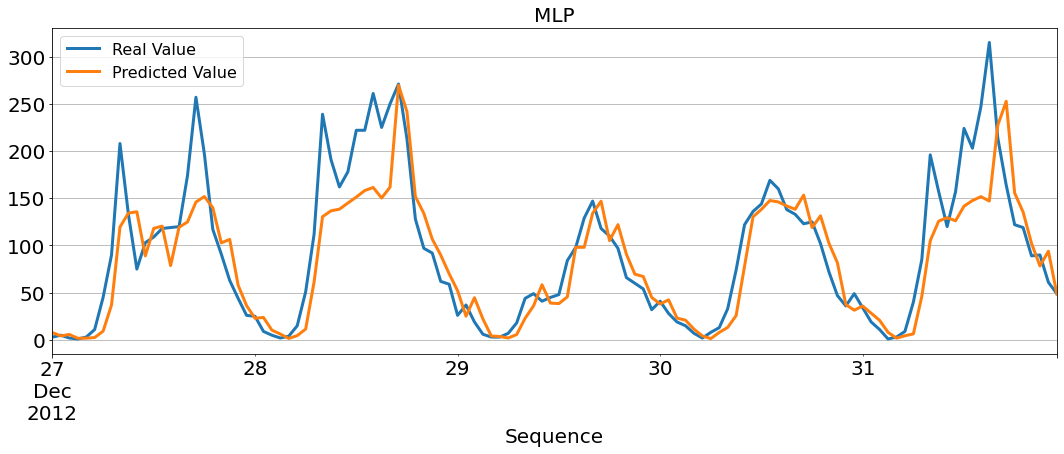

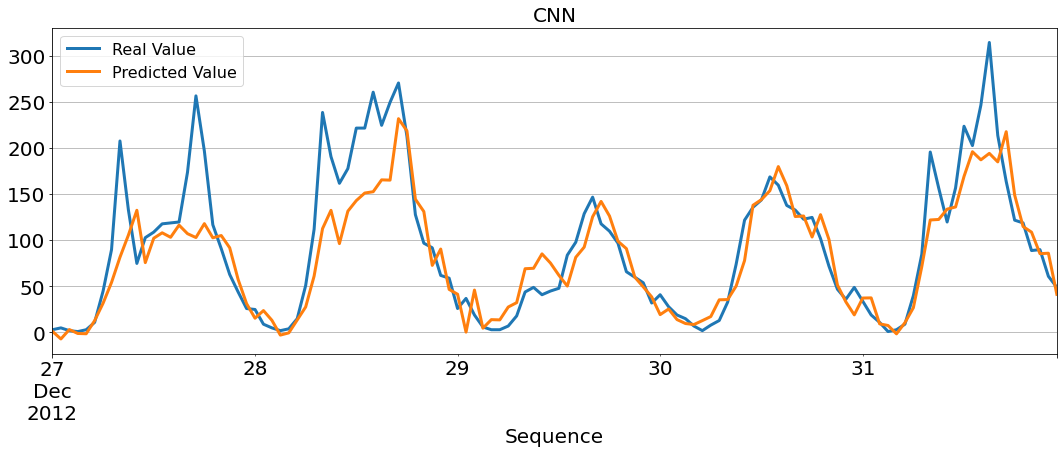

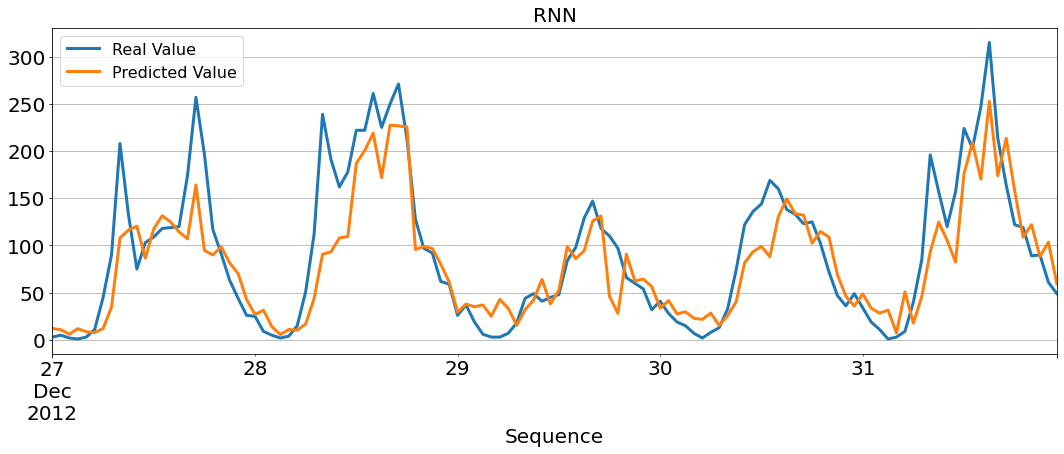

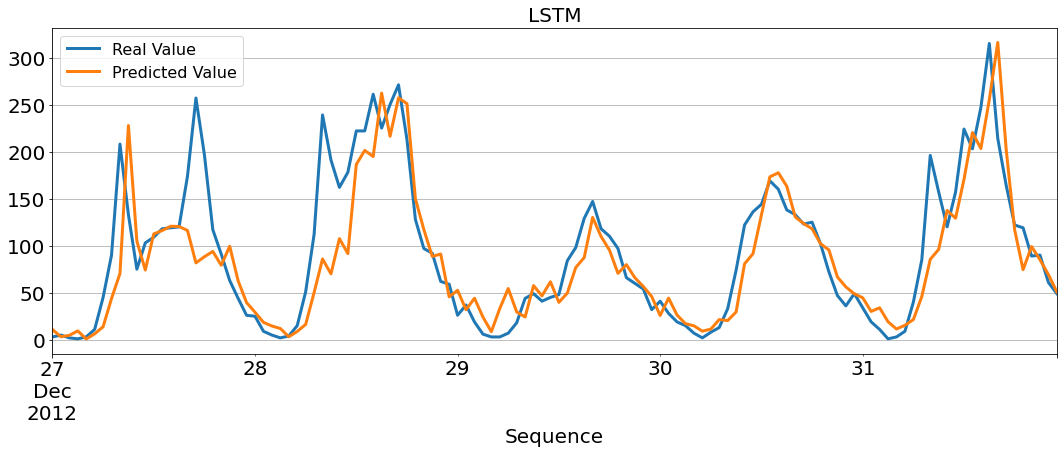

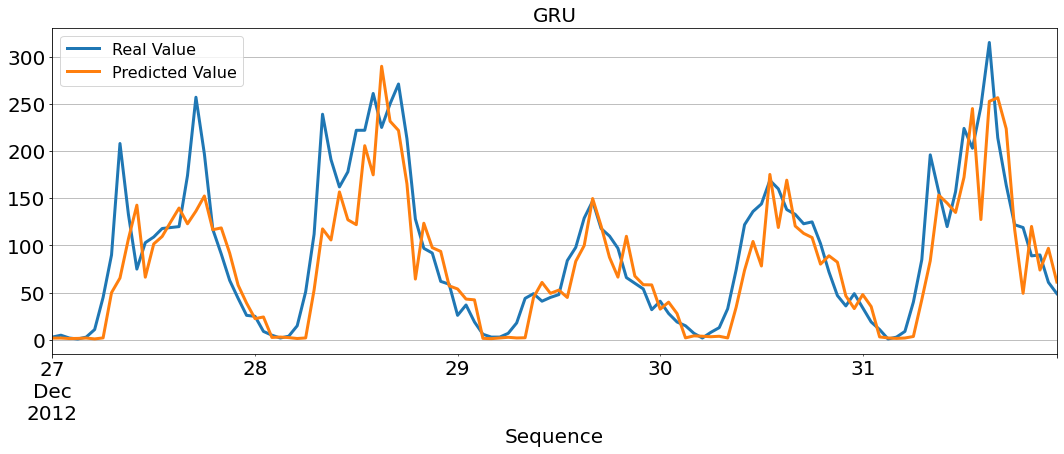

In [17]:
evaluation_reg_PredPlot(Y_real, Y_pred_MLP, title=ALGO_NAMES[0], ylabel='')
evaluation_reg_PredPlot(Y_real, Y_pred_CNN, title=ALGO_NAMES[1], ylabel='')
evaluation_reg_PredPlot(Y_real, Y_pred_RNN, title=ALGO_NAMES[2], ylabel='')
evaluation_reg_PredPlot(Y_real, Y_pred_LSTM, title=ALGO_NAMES[3], ylabel='')
evaluation_reg_PredPlot(Y_real, Y_pred_GRU, title=ALGO_NAMES[4], ylabel='')